# Strava Fitness Data Analytics Case-Study
## Bellabeat: How Can a Wellness Technology Company Play It Smart?
### From recorded days to credible habits

**Portfolio case study | Supplied Fitbit / MTurk data | 12 April–12 May 2016**

The deck title is retained for submission continuity. These are **Fitbit exports, not Strava product telemetry**.

**Executive decision:** Focus on the **Bellabeat App/Membership**, interpreted as the product option in the case brief. Activity and sleep onboarding, reminder timing and retention experiments can be tested together in an app. These exports contain no hydration, purchase, acquisition-cost or subscription-conversion data, so they cannot justify a Spring launch, hardware revenue forecast or an ROI claim. Recommendations below are proposed experiments, not claims about current product features.

**Objective:** Describe device-use patterns, separate recording quality from movement, and propose measurable marketing experiments for this one product.

**Stakeholders:** Urška Sršen (co-founder and CCO), Sando Mur (co-founder), and Bellabeat marketing analytics team.

**Business questions:**
1. How much of the observed activity is credible under a transparent wear-quality proxy?
2. Which features have broad versus concentrated adoption?
3. When do activity patterns create opportunities for opt-in reminders?
4. How do sleep, activity and exertion relate, with repeated users handled correctly?
5. Which behavioural segments could guide onboarding and retention experiments?

**Tools:** Python, pandas, NumPy, SciPy, scikit-learn, Matplotlib, Seaborn, PyArrow and SQLite.

### Table of contents
0. [Configuration](#section-0)
1. [Sources and dictionary](#section-1)
2. [Integrity audit](#section-2)
3. [Cleaning and features](#section-3)
4. [Univariate EDA](#section-4)
5. [Bivariate and multivariate EDA](#section-5)
6. [Time and behaviour](#section-6)
7. [Sleep](#section-7)
8. [Heart rate and intensity](#section-8)
9. [Weight logging](#section-9)
10. [Segmentation](#section-10)
11. [Statistical validation](#section-11)
12. [Key findings](#section-12)
13. [Marketing recommendations](#section-13)
14. [Limitations and next steps](#section-14)
15. [Reproducibility appendix](#section-15)

<a id="section-0"></a>
## 0. Configuration

**Takeaway:** All paths are relative; both analytical paths rebuild from the supplied CSVs.

Run from the `outputs/` directory. Put the extracted original archive under `../raw/`, or set `FITBIT_RAW_DIR`. The database is regenerated if absent. The first full run imports all 18 files and can take several minutes. Parquet aggregates are refreshed for downstream use. No Power BI or Streamlit application is created.

In [1]:
from pathlib import Path
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from load_csv_to_sqlite import import_files
from run_sql import run_sql
from analysis_utils import prepare_data, plot_chart, PALETTE, SEED

BASE = Path.cwd()
RAW_DIR = Path(r"C:\Users\Dell\Downloads\Data Files\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16")
print("CSV files found:", len(list(RAW_DIR.rglob("*.csv"))))
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette=PALETTE)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 35)
for folder in ["processed", "charts", "sql_outputs"]:
    (BASE / folder).mkdir(exist_ok=True)
if not (BASE / "bellabeat.db").exists():
    import_files(RAW_DIR, BASE / "bellabeat.db")
execution_log = run_sql(BASE)
assert execution_log.status.eq("PASS").all()
print(f"SQL validation: {len(execution_log)} statements executed successfully")
data = prepare_data(BASE)
d, s, w, u = [data[key] for key in ["d", "s", "w", "u"]]


CSV files found: 18
dailyActivity: CSV 940 x 15 -> SQLite 940 x 15; 33 users; 0 duplicates
dailyCalories: CSV 940 x 3 -> SQLite 940 x 3; 33 users; 0 duplicates
dailyIntensities: CSV 940 x 10 -> SQLite 940 x 10; 33 users; 0 duplicates
dailySteps: CSV 940 x 3 -> SQLite 940 x 3; 33 users; 0 duplicates
heartrate_seconds: CSV 2,483,658 x 3 -> SQLite 2,483,658 x 3; 14 users; 0 duplicates
hourlyCalories: CSV 22,099 x 3 -> SQLite 22,099 x 3; 33 users; 0 duplicates
hourlyIntensities: CSV 22,099 x 4 -> SQLite 22,099 x 4; 33 users; 0 duplicates
hourlySteps: CSV 22,099 x 3 -> SQLite 22,099 x 3; 33 users; 0 duplicates
minuteCaloriesNarrow: CSV 1,325,580 x 3 -> SQLite 1,325,580 x 3; 33 users; 0 duplicates
minuteCaloriesWide: CSV 21,645 x 62 -> SQLite 21,645 x 62; 33 users; 0 duplicates
minuteIntensitiesNarrow: CSV 1,325,580 x 3 -> SQLite 1,325,580 x 3; 33 users; 0 duplicates
minuteIntensitiesWide: CSV 21,645 x 62 -> SQLite 21,645 x 62; 33 users; 0 duplicates
minuteMETsNarrow: CSV 1,325,580 x 3 -> SQ

<a id="section-1"></a>
## 1. Data sources and data dictionary

**Takeaway:** 18 files contain overlapping grains; none provides demographics or app revenue.

**Source supplied in the brief:** Kaggle/Mobius Fitbit public export collected through Amazon Mechanical Turk. The deck cites DOI `10.5281/zenodo.53894`. Provenance and consent are reported by the brief, not independently certified here. The deck's broader March–May collection description does not describe this archive's daily analysis window.

The table below is based on a full scan, not a sample. Date bounds are raw export bounds, so minute sleep can start the previous evening and wide minute files can extend beyond the selected daily window. `source_inventory` includes source SHA-256 hashes and file sizes; `column_audit` lists **every column**, SQLite type, missing count and negative count.

| table_name              | grain                            |    rows |   columns |   users | start               | end                 | purpose                                    |
|:------------------------|:---------------------------------|--------:|----------:|--------:|:--------------------|:--------------------|:-------------------------------------------|
| dailyActivity           | user-day                         |     940 |        15 |      33 | 2016-04-12          | 2016-05-12          | Canonical activity and calories            |
| dailyCalories           | user-day                         |     940 |         3 |      33 | 2016-04-12          | 2016-05-12          | Redundant daily calories                   |
| dailyIntensities        | user-day                         |     940 |        10 |      33 | 2016-04-12          | 2016-05-12          | Redundant daily activity minutes/distances |
| dailySteps              | user-day                         |     940 |         3 |      33 | 2016-04-12          | 2016-05-12          | Redundant daily steps                      |
| heartrate_seconds       | user-timestamp                   | 2483658 |         3 |      14 | 2016-04-12 00:00:00 | 2016-05-12 16:20:00 | Irregular heart-rate observations          |
| hourlyCalories          | user-hour                        |   22099 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:00:00 | Hourly calorie rhythm                      |
| hourlyIntensities       | user-hour                        |   22099 |         4 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:00:00 | Hourly raw intensity score                 |
| hourlySteps             | user-hour                        |   22099 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:00:00 | Hourly movement timing                     |
| minuteCaloriesNarrow    | user-timestamp                   | 1325580 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:59:00 | Minute energy estimates                    |
| minuteCaloriesWide      | user-hour with 60 minute columns |   21645 |        62 |      33 | 2016-04-13 00:00:00 | 2016-05-13 08:00:00 | Wide minute energy; different coverage     |
| minuteIntensitiesNarrow | user-timestamp                   | 1325580 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:59:00 | Minute intensity codes                     |
| minuteIntensitiesWide   | user-hour with 60 minute columns |   21645 |        62 |      33 | 2016-04-13 00:00:00 | 2016-05-13 08:00:00 | Wide minute codes; different coverage      |
| minuteMETsNarrow        | user-timestamp                   | 1325580 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:59:00 | Raw METs exertion field                    |
| minuteSleep             | user-timestamp-log               |  188521 |         4 |      24 | 2016-04-11 20:48:00 | 2016-05-12 09:56:00 | Sleep episode/code timestamps              |
| minuteStepsNarrow       | user-timestamp                   | 1325580 |         3 |      33 | 2016-04-12 00:00:00 | 2016-05-12 15:59:00 | Minute movement                            |
| minuteStepsWide         | user-hour with 60 minute columns |   21645 |        62 |      33 | 2016-04-13 00:00:00 | 2016-05-13 08:00:00 | Wide minute movement; different coverage   |
| sleepDay                | user-day                         |     413 |         5 |      24 | 2016-04-12 00:00:00 | 2016-05-12 00:00:00 | Daily sleep totals                         |
| weightLogInfo           | user-timestamp                   |      67 |         8 |       8 | 2016-04-12 06:47:11 | 2016-05-12 23:59:59 | Weight/BMI logging behaviour               |

| Field family | Meaning and analytical treatment |
|---|---|
| Id, logId / LogId | 64-bit identifiers, never numeric predictors |
| ActivityDate/Day/Hour/Minute, SleepDay, Date, Time, date | US dates explicitly parsed at import; ISO text in SQLite, explicit ISO parsing in pandas |
| TotalSteps / StepTotal / Steps00–59 | Counts of recorded steps at the stated grain |
| Calories / Calories00–59 | Exported energy estimate, treated as kcal; daily totals include basal energy and are not exercise calories |
| Very/Fairly/LightlyActiveMinutes; SedentaryMinutes | Device-classified minutes; not verified on-body wear duration |
| TotalDistance, TrackerDistance, activity distances | Export units undocumented in attached files; retained without km/mile interpretation |
| Intensity, TotalIntensity, AverageIntensity | Raw device score/code, not a physical unit or minutes of exercise |
| METs | Raw integer export score; scaling not verified, so no division by 10 or clinical MET threshold |
| Heart-rate Value | Recorded beats/minute; descriptive bands, no age-based zones |
| TotalMinutesAsleep, TotalTimeInBed, TotalSleepRecords | Daily sleep minutes, in-bed minutes and record count |
| minuteSleep value | Unverified state code; retained as code 1/2/3, not relabeled as sleep stages |
| WeightKg, WeightPounds, Fat, BMI, IsManualReport | Weight units explicit in field names; Fat sparse; BMI retained as reported; boolean reporting method |

**Redundancy verification:** all three daily subsets agree with `dailyActivity`. Wide/narrow pairs agree on overlapping minute timestamps, but their coverage differs. They must not be appended together or counted as additional users.

In [2]:
display(data["redundancy"])

,comparison,overlap_rows,missing_keys,mismatched_values
0,dailySteps vs dailyActivity,940,0,0
1,dailyCalories vs dailyActivity,940,0,0
2,dailyIntensities vs dailyActivity,940,0,0
3,minuteSteps wide/narrow,1278060,20640,0
4,minuteIntensities wide/narrow,1278060,20640,0
5,minuteCalories wide/narrow,1278060,20640,0


<a id="section-2"></a>
## 2. Data integrity and quality audit

**Takeaway:** Missing wear information and uneven modality coverage matter more than nominal row volume.

In [3]:
display(data["quality"])
display(data["inventory"][["table_name", "rows", "users", "duplicate_rows", "duplicate_keys", "megabytes"]])
display(data["columns"].query("null_rows > 0 or negative_rows > 0"))

,check,count,status,interpretation
0,Participants vs brief,33.0,Review,33 activity users vs 30 stated
1,Exact sleep duplicates,3.0,Fixed,413 raw rows -> 410 unique
2,Minute sleep duplicates,543.0,Fixed,Deduplicated before episode aggregation
3,Zero-step days,77.0,Flagged,May be nonwear or true inactivity
4,Near-zero days (<100),87.0,Excluded,Proxy threshold; sensitivity table retained
5,Sedentary =1440,79.0,Excluded,24 hours; does not establish actual nonwear
6,Classified minutes >1440,0.0,Review,Impossible full-day duration if present
7,Missing Fat,65.0,Retained,Do not impute sparse body-fat field
8,Multiple sleep records,46.0,Retained,Possible split sleep/naps; no automatic deletion
9,Asleep exceeds in-bed,0.0,Checked,Reject impossible records if present


,table_name,rows,users,duplicate_rows,duplicate_keys,megabytes
0,dailyActivity,940,33,0,0,0.11
1,dailyCalories,940,33,0,0,0.03
2,dailyIntensities,940,33,0,0,0.07
3,dailySteps,940,33,0,0,0.03
4,heartrate_seconds,2483658,14,0,0,89.59
5,hourlyCalories,22099,33,0,0,0.80
6,hourlyIntensities,22099,33,0,0,0.90
7,hourlySteps,22099,33,0,0,0.80
8,minuteCaloriesNarrow,1325580,33,0,0,66.44
9,minuteCaloriesWide,21645,33,0,0,22.99


,table_name,column_name,storage_type,null_rows,negative_rows
255,weightLogInfo,Fat,REAL,65,0


**Mismatches against the brief/deck:**
- Activity has **33** users rather than 30. Sleep has **24**, heart rate **14**, weight **8**. No demographic restriction to women is possible.
- Daily activity has **940 rows**, daily sleep **413 raw / 410 unique**, weight **67**, hourly steps **22,099**, heart rate **2,483,658** (89.59 MB). The approximate counts supplied are consistent.
- Minute-wide files are only 3.31–22.99 MB; the 45–65 MB description applies mainly to narrow activity exports (minute calories is 66.44 MB in decimal units). `minuteSleep` is 8.85 MB.
- Wide activity extends to **May 13 08:00**, and minute sleep begins **April 11 20:48**. Daily analysis remains April 12–May 12 inclusive, exactly **31 days**. Crossing months does not itself create an inconsistent time frame.
- There are **21** users with all 31 activity dates; users have **4–31** logged dates. Coverage is not a measure of diligence or motivation.
- **77** zero-step days and **79** days with 1,440 sedentary minutes are suspicious, not proof of nonwear. 1,440 minutes equals **24 hours**.
- Weight Fat has **65/67** missing cells, contradicting the deck's blanket “no blanks” claim. Daily sleep has **3** duplicate rows and minute sleep **543**.
- Heart-rate intervals are irregular; fixed 15-second sampling cannot be assumed. A full interval-frequency table is exported in `sql_outputs/hr_sampling_audit.csv`.
- The deck's 10,000-step “CDC requirement” and gender-based calorie-burn conclusions are not supported. The step tiers here are descriptive historical pedometer tiers specified by the task, not a universal health prescription.


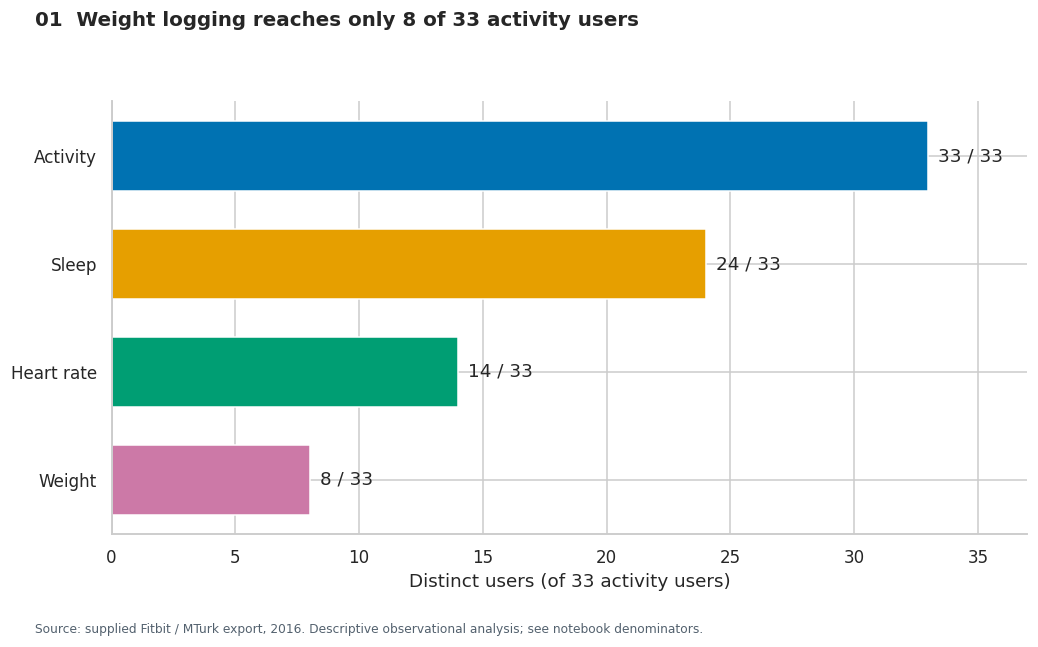

In [4]:
plot_chart(1, data)

**So what?** Use activity-led onboarding as the broad entry point. Separate feature adoption counts are not a sequential conversion funnel and do not establish user preference or device capability.

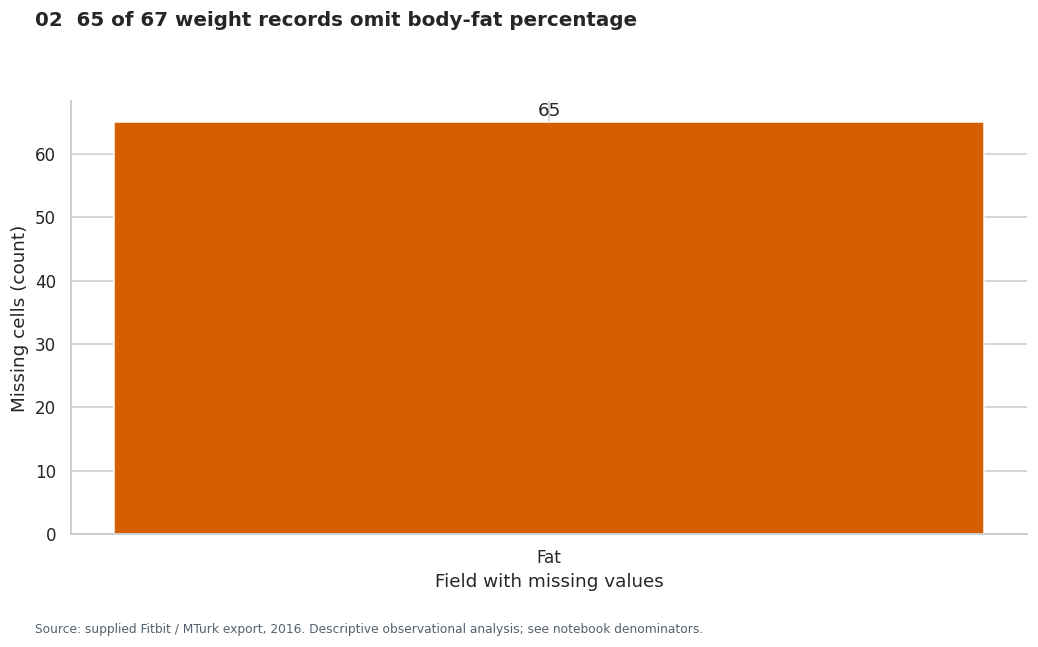

In [5]:
plot_chart(2, data)

**So what?** Do not segment or market from body-fat estimates: only 2 of 67 weight logs contain Fat, and no missing value is imputed.

In [6]:
display(u[["Id", "first_date", "last_date", "days_logged", "valid_days", "engagement_score"]].sort_values("valid_days"))
display(pd.read_csv(BASE / "sql_outputs/hr_value_audit.csv"))
display(pd.read_csv(BASE / "sql_outputs/hr_sampling_audit.csv").head(12))

,Id,first_date,last_date,days_logged,valid_days,engagement_score
13,4057192912,2016-04-12,2016-04-15,4,3,9.677419
12,4020332650,2016-04-12,2016-05-12,31,15,48.387097
23,6775888955,2016-04-12,2016-05-07,26,16,51.612903
4,1927972279,2016-04-12,2016-05-12,31,17,54.838710
8,2347167796,2016-04-12,2016-04-29,18,17,54.838710
3,1844505072,2016-04-12,2016-05-12,31,18,58.064516
28,8253242879,2016-04-12,2016-04-30,19,18,58.064516
31,8792009665,2016-04-12,2016-05-10,29,19,61.290323
10,3372868164,2016-04-12,2016-05-01,20,20,64.516129
21,6117666160,2016-04-12,2016-05-09,28,23,74.193548


,readings,min_bpm,max_bpm,out_of_bounds
0,2483658,36.0,203.0,0


,seconds,intervals
0,5.0,868956
1,10.0,622040
2,15.0,557885
3,3.0,245262
4,1.0,120929
5,2.0,65203
6,6.0,697
7,7.0,277
8,45.0,213
9,4.0,196


<a id="section-3"></a>
## 3. Cleaning and feature engineering

**Takeaway:** The transparent quality proxy retains 846 of 940 daily records; the raw series remains available.

In [7]:
display(data["cleaning"])
display(data["sensitivity"])

,issue,action,rows_before,rows_after,columns_before,columns_after,justification
0,Exact activity duplicates,Deduplicate activity,940,940,15,15,Retain one identical record
1,Probable nonwear / negligible motion,Apply wear-quality proxy,940,846,17,17,Steps >=100 and sedentary <1440; excludes true low movement too; sensitivity reported
2,Analytical features,Engineer daily features,846,846,17,26,Active share denominator is classified minutes; calories include basal expenditure
3,Exact sleep duplicates,Deduplicate sleep,413,410,5,5,Remove identical daily records
4,Impossible sleep values,Validate sleep,410,410,5,5,"Positive duration, asleep <= in-bed <=1440"
5,Weight validity and missing Fat,Validate weight; retain missing Fat,67,67,8,8,"No imputation; analyse logging, not weight change or health"
6,Hourly coverage,Restrict hours to retained activity dates,22099,20045,3,11,No imputation for absent hours; averages use observed user-hours
7,Duplicate minute sleep rows,Aggregate unique sleep minutes to episodes,188521,459,4,8,Exact deduplication in SQL; raw code labels not interpreted as clinical stages
8,Repeated user-days,Aggregate user features and attach personas,846,33,27,17,One observation per user for clustering and inference
9,Calendar alignment,Join sleep to exact adjacent activity dates,410,410,11,6,Left joins preserve sleep days; unmatched activity remains missing


,minimum_steps,days,mean_steps
0,1,856,8328.693925
1,100,846,8426.832151
2,500,835,8534.583234
3,1000,824,8638.453883


**Cleaning contract:** retain exact-unique daily activity rows with **TotalSteps ≥100 and SedentaryMinutes <1,440**. This operational proxy excludes plausible nonwear and near-zero motion; it also removes some genuinely inactive days. Never label it confirmed wear time. No extra calorie or distance exclusion is applied. Preserve all raw rows with the flag in `flagged_daily_activity`.

Exact-duplicate sleep rows are removed. Retain positive sleep with asleep ≤ in-bed ≤1,440. Sleep results use all valid sleep records, not only activity-filtered dates. Retain positive WeightKg and BMI, leaving Fat missing. Multiple weight logs remain separate; aggregate to user-day before daily joins. Unique minute-sleep records are aggregated to episodes. HR summaries use 30–220 bpm as a broad plausibility screen; intervals over 60 seconds and final readings with no following observation contribute no duration.

**Features:** weekday/weekend, study day/week, four hour buckets; five requested step tiers; active minutes = light + fairly + very active; active share = active / (active + sedentary classified minutes); sleep efficiency = asleep / in-bed; calories per step = total kcal / steps (not energy cost per step); days logged; engagement = retained days / 31 ×100. Full-window engagement intentionally penalizes missing enrollment days because enrollment dates are unavailable.

**WHO-inspired flag:** sum fairly-active minutes + 2 × very-active minutes across each of four complete seven-day study windows starting April 12. Only a user-week with all seven retained days is eligible; threshold ≥150 moderate-equivalent minutes. A separate moderate-only ≥150-minute flag is also exported. The final three days are excluded from weekly flags. Fitbit categories are imperfect intensity proxies; strength training and other guideline components cannot be assessed. This is **not a verified health-guideline compliance measure**. [WHO physical activity guidance](https://www.who.int/news-room/fact-sheets/detail/physical-activity).

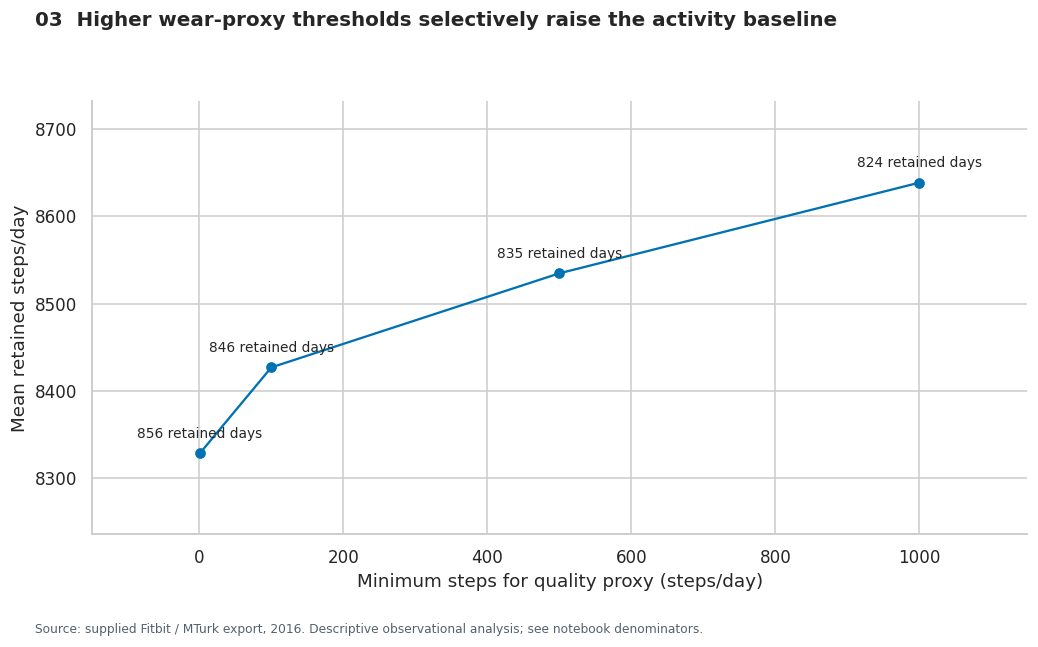

In [8]:
plot_chart(3, data)

**So what?** The main rule removes 94 days (10.0%). Raw mean steps are 7,638; the retained mean is 8,427. This increase is selection, not an intervention effect.

<a id="section-4"></a>
## 4. Univariate EDA

**Takeaway:** Typical activity and recording consistency are different dimensions of device use.

In [9]:
display(d[["TotalSteps", "Calories", "active_minutes", "SedentaryMinutes", "active_share"]].describe().round(2))
display(s[["TotalMinutesAsleep", "sleep_efficiency", "in_bed_gap"]].describe().round(2))

,TotalSteps,Calories,active_minutes,SedentaryMinutes,active_share
count,846.00,846.00,846.00,846.00,846.00
mean,8426.83,2370.38,252.76,949.53,0.22
std,4695.87,697.26,100.55,271.81,0.10
min,108.00,52.00,3.00,13.00,0.00
25%,4981.75,1861.50,190.00,720.25,0.16
50%,8115.00,2222.50,259.00,1017.50,0.23
75%,11128.00,2835.00,324.00,1182.00,0.28
max,36019.00,4900.00,552.00,1437.00,0.61


,TotalMinutesAsleep,sleep_efficiency,in_bed_gap
count,410.00,410.00,410.00
mean,419.17,0.92,39.31
std,118.64,0.09,46.71
min,58.00,0.50,0.00
25%,361.00,0.91,17.00
50%,432.50,0.94,25.50
75%,490.00,0.96,40.00
max,796.00,1.00,371.00


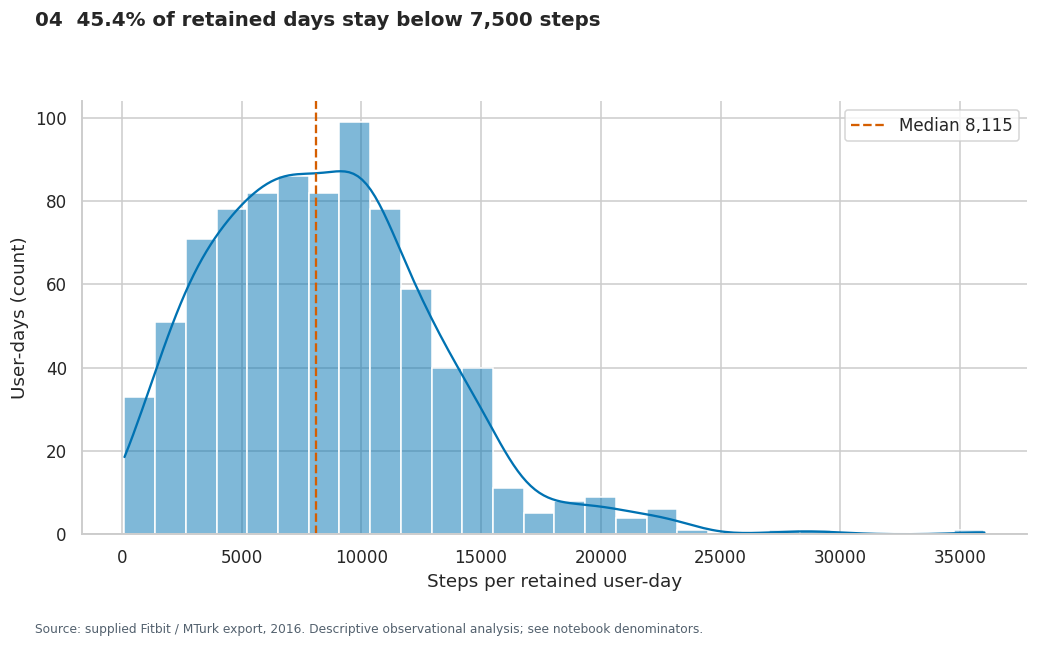

In [10]:
plot_chart(4, data)

**So what?** 45.4% of retained days are below 7,500 steps. Set an individual baseline before offering a stretch goal; the tiers do not diagnose health.

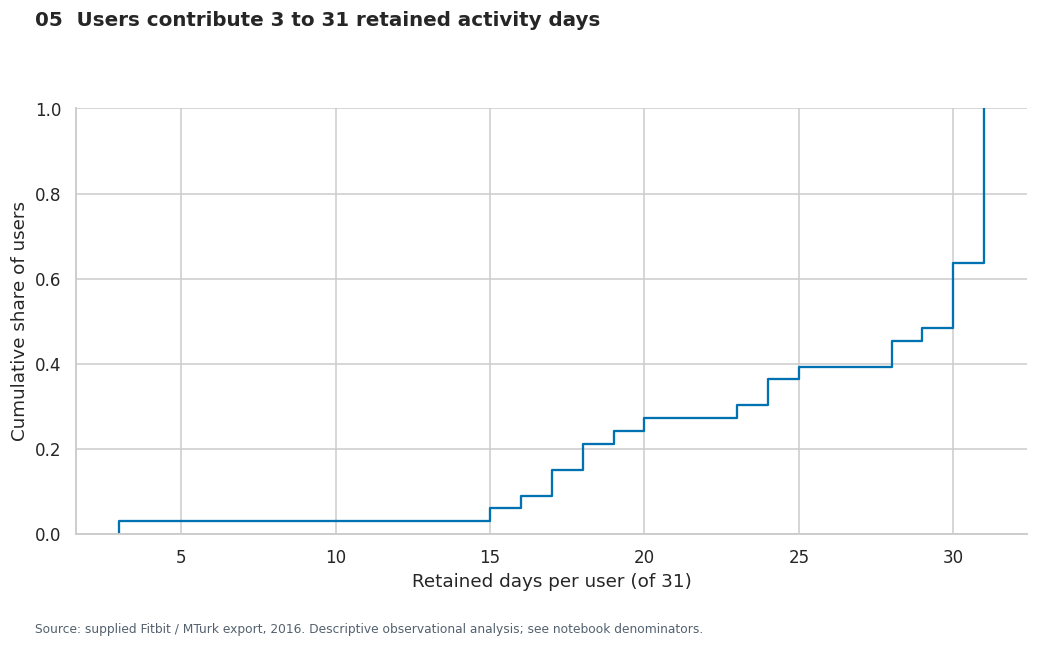

In [11]:
plot_chart(5, data)

**So what?** Every user has at least one retained day, but a common 31-day denominator reveals uneven recording opportunity. Logged rows alone overstate usable activity coverage.

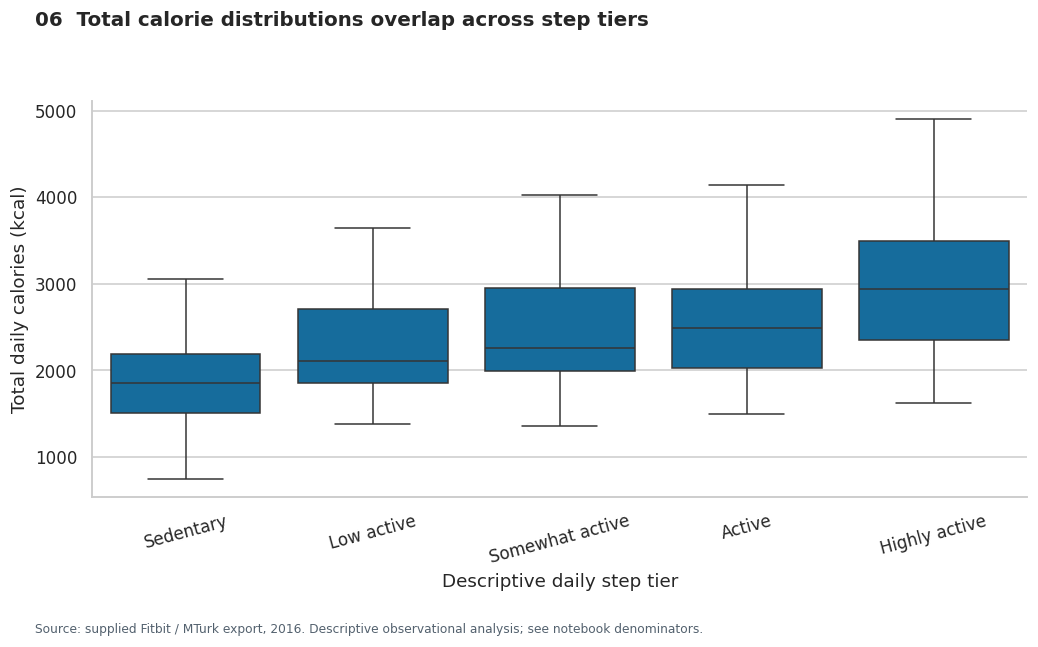

In [12]:
plot_chart(6, data)

**So what?** Calories are daily total expenditure estimates and vary between people. These records cannot establish calorie intake, an energy deficit or a gender-specific target.

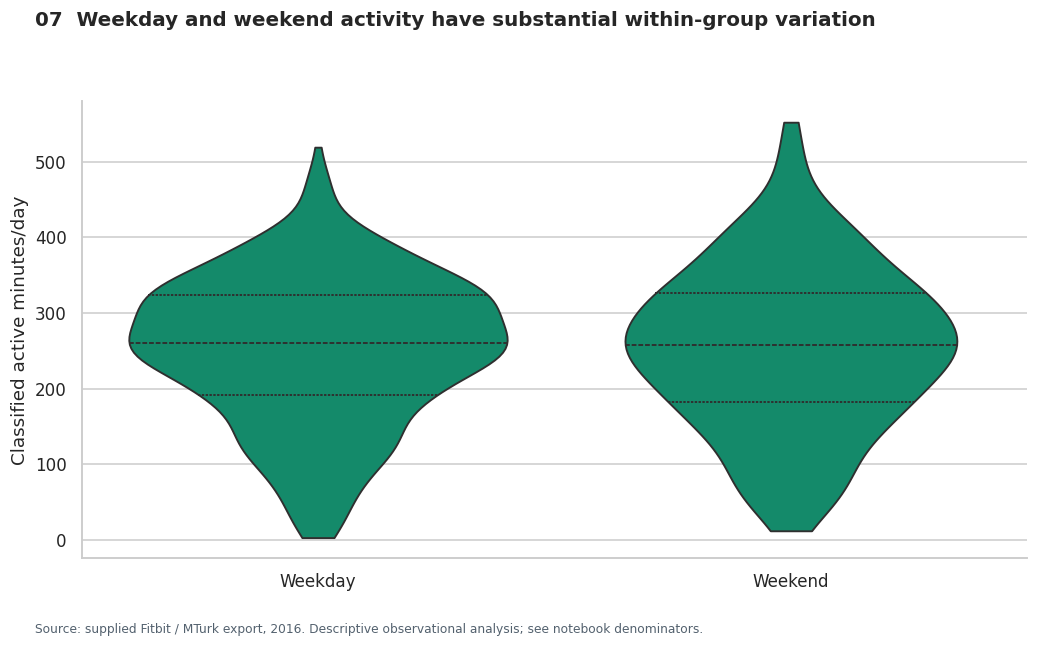

In [13]:
plot_chart(7, data)

**So what?** Wide overlapping daily distributions argue against one universal weekend reminder. Repeated days are descriptive here; the formal weekend comparison pairs user means.

<a id="section-5"></a>
## 5. Bivariate and multivariate EDA

**Takeaway:** Daily associations should not be mistaken for independent evidence from hundreds of people.

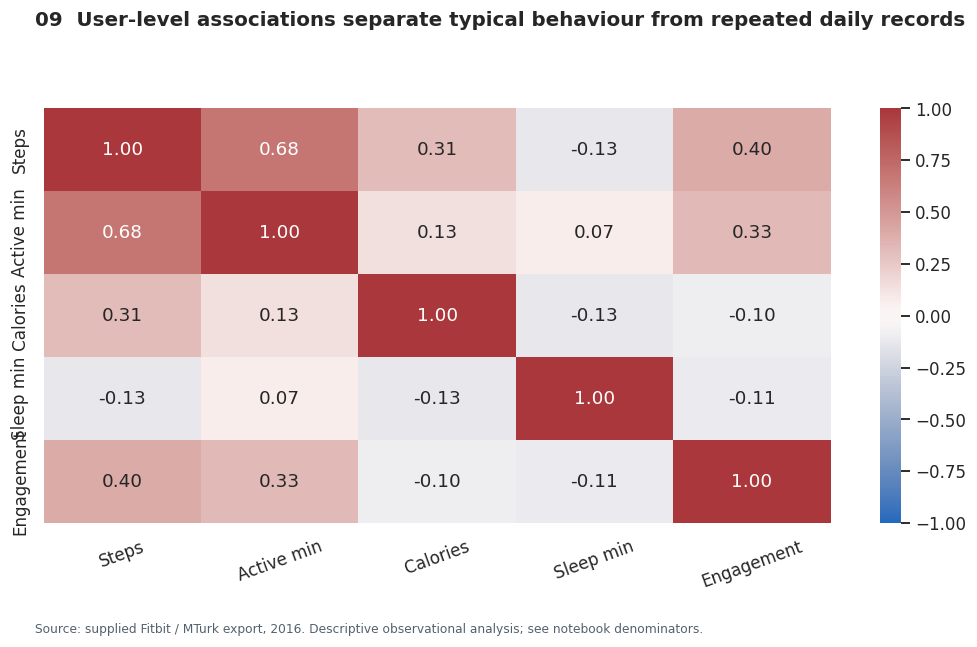

In [14]:
plot_chart(9, data)

**So what?** Pairwise correlations use one mean per user. Sleep pairs involve only the 24 sleep loggers; differences in observation days still limit comparability.

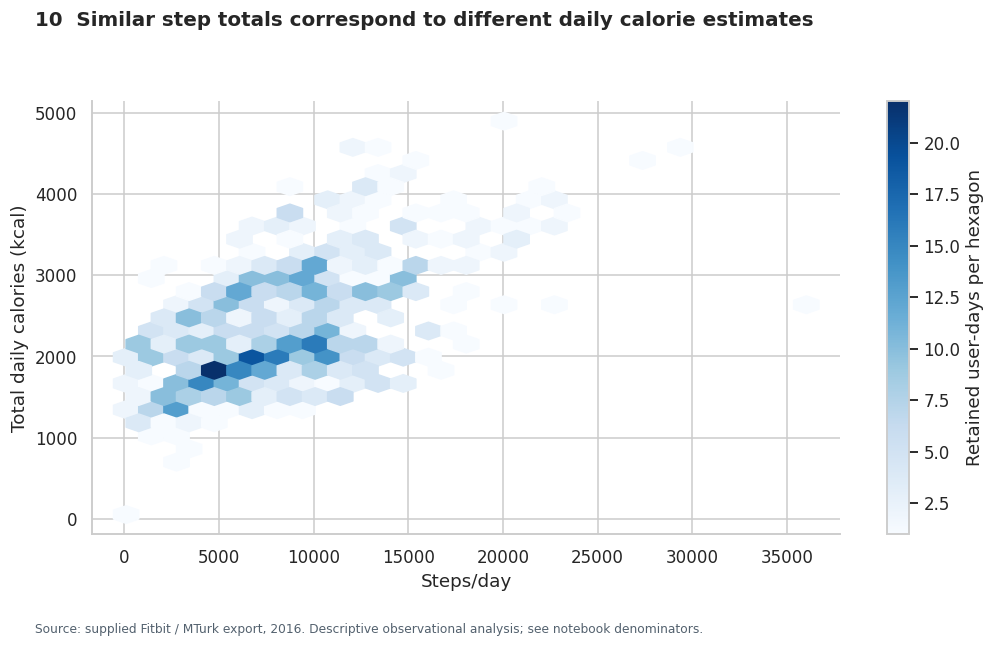

In [15]:
plot_chart(10, data)

**So what?** Steps alone cannot explain total calorie differences. Basal expenditure, unmeasured body characteristics and non-step activities remain potential confounders.

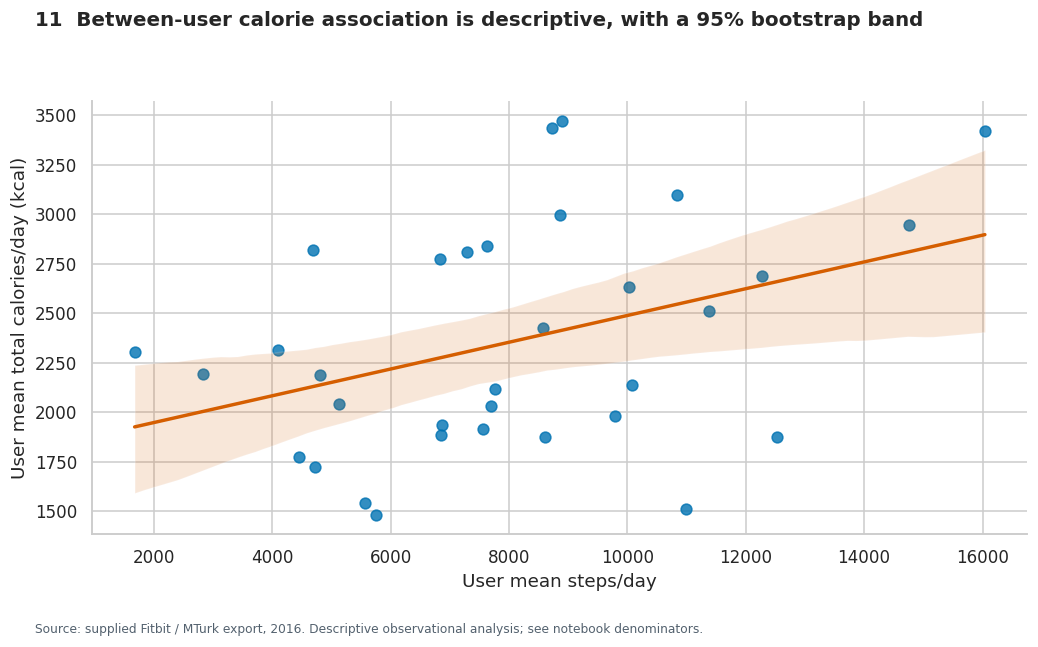

In [16]:
plot_chart(11, data)

**So what?** The shaded interval resamples user summaries. With 33 users, a visible fitted trend is insufficient to support a causal or personalized calorie claim.

<a id="section-6"></a>
## 6. Time and behaviour patterns

**Takeaway:** Use observed timing to design experiments, while distinguishing calendar coverage from retention.

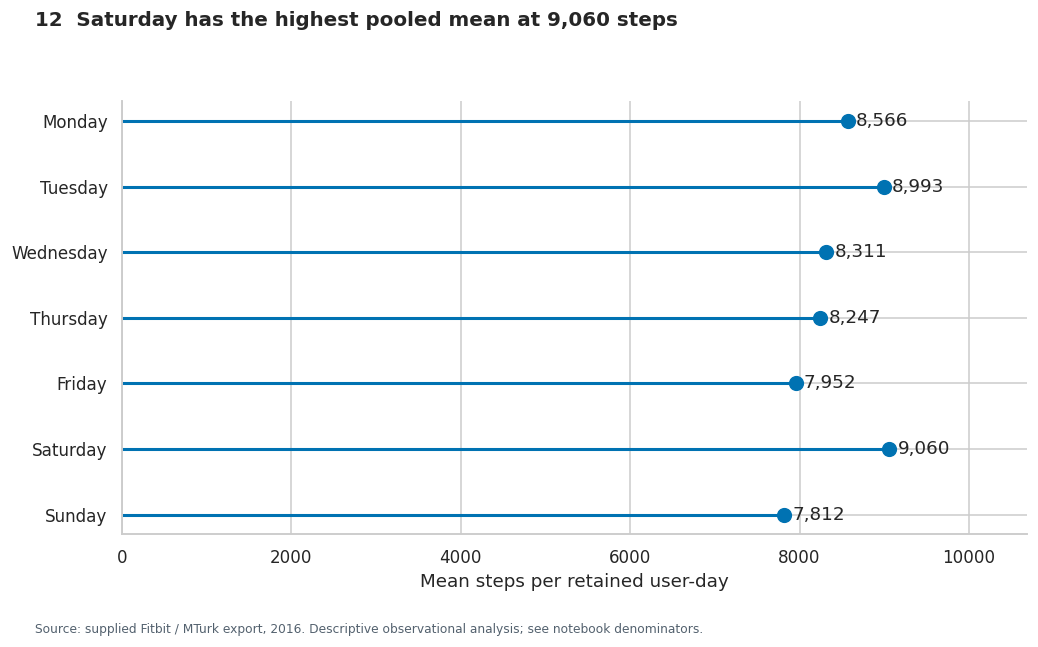

In [17]:
plot_chart(12, data)

**So what?** The weekday ranking pools retained days. Different users and different counts contribute on each weekday, so it is not a within-person causal comparison.

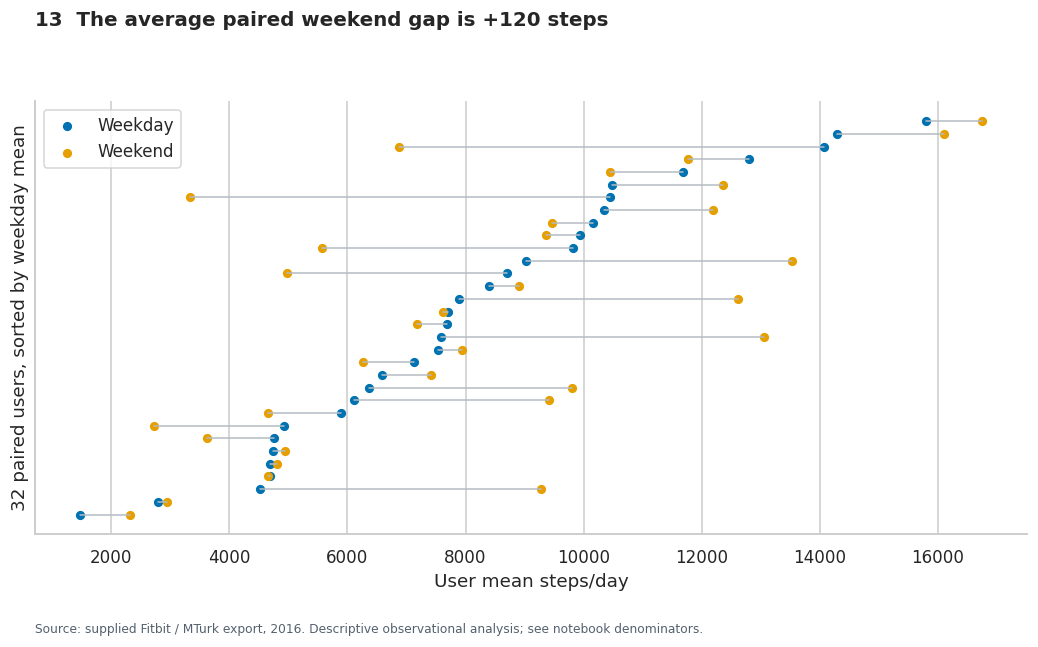

In [18]:
plot_chart(13, data)

**So what?** Among 32 users observed in both groups, the mean weekend-minus-weekday gap is +120 steps (95% user-bootstrap CI -959 to +1143). The interval includes zero.

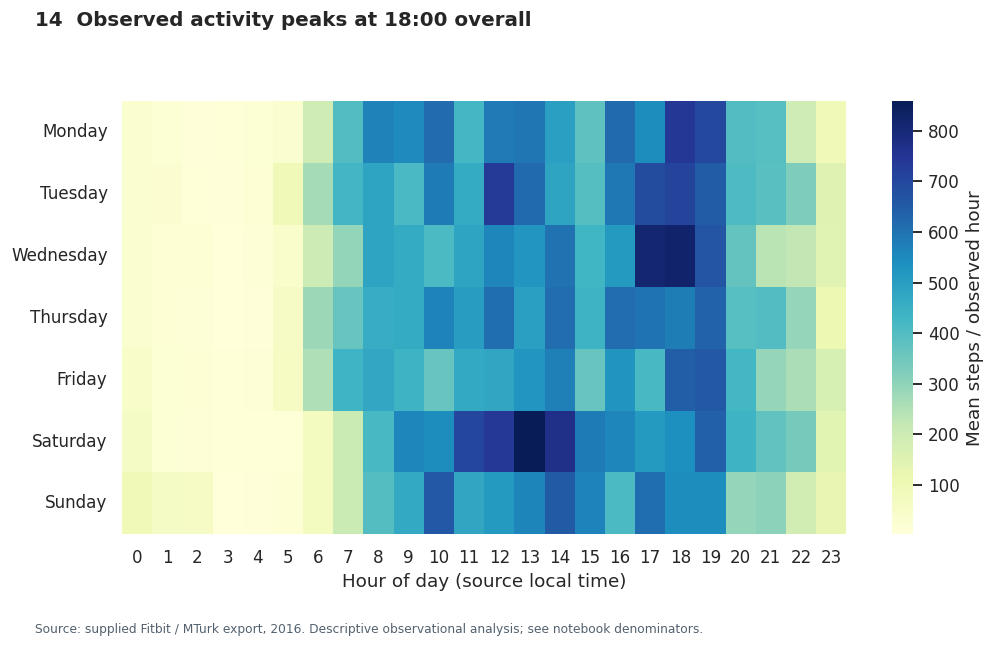

In [19]:
plot_chart(14, data)

**So what?** The overall peak is 18:00, averaging 660 steps per observed retained-day hour. Test reminder timing around individual patterns; recorded peak movement is not proven optimal notification timing.

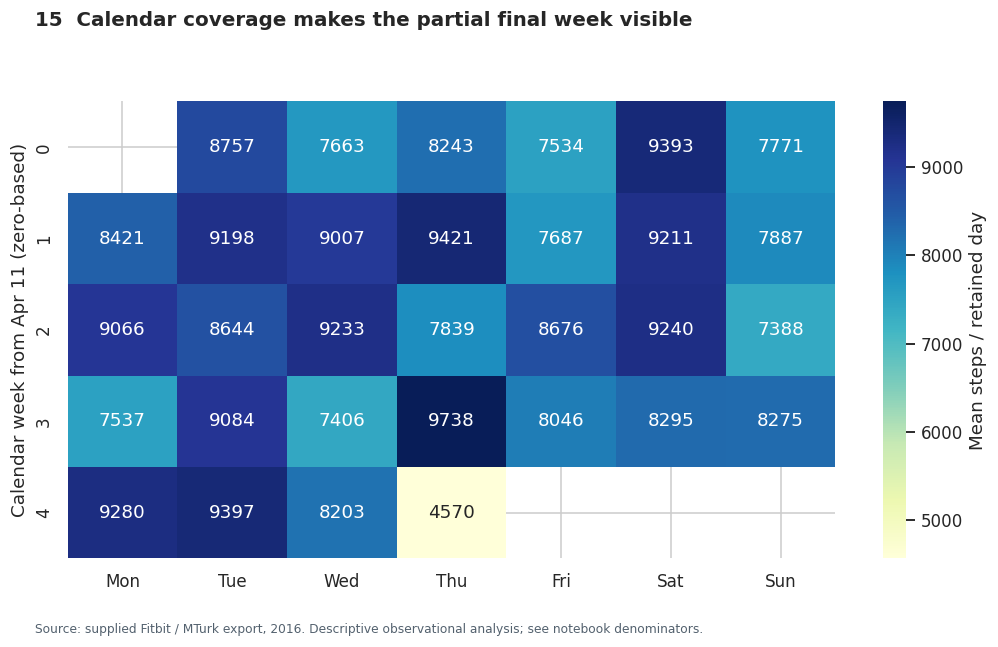

In [20]:
plot_chart(15, data)

**So what?** Blank cells fall outside the study window. The partially observed final day and changing user mix can depress daily means, so do not call the pattern behavioural decline.

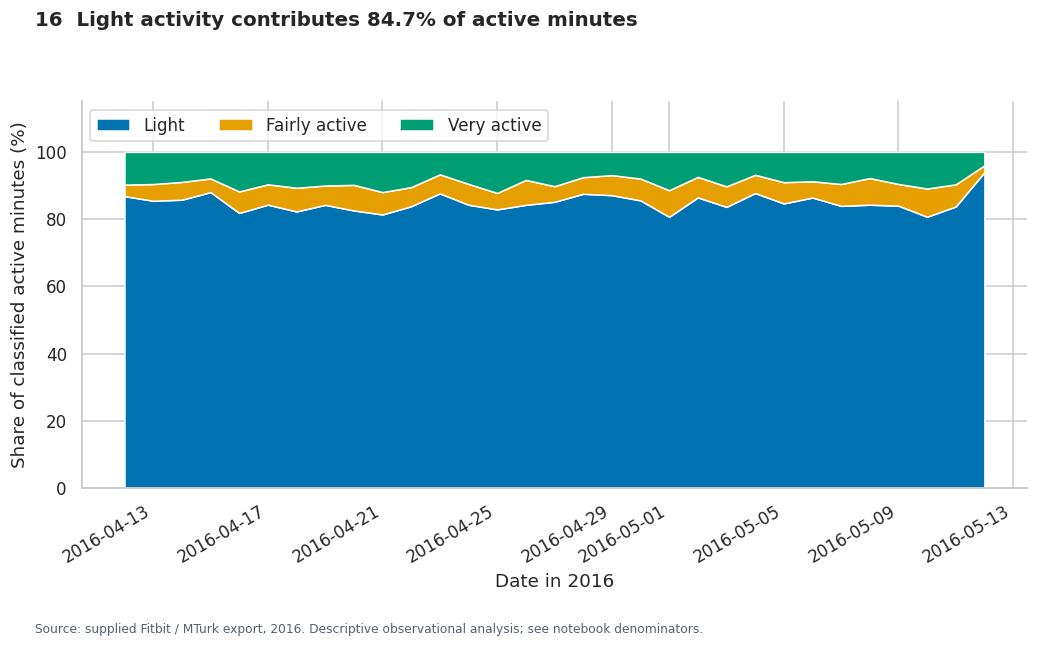

In [21]:
plot_chart(16, data)

**So what?** Light minutes account for 84.7% of classified active time. Short movement prompts are a relevant test; light activity is not substituted for moderate intensity in the weekly flag.

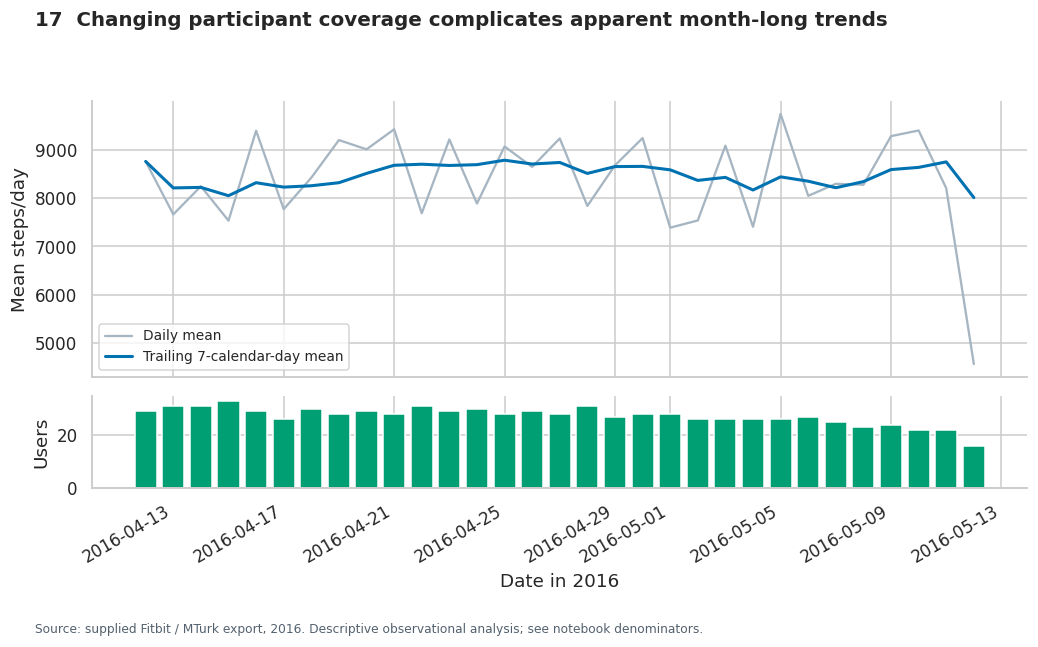

In [22]:
plot_chart(17, data)

**So what?** The lower panel shows the changing denominator. A trailing mean smooths daily variation but does not correct attrition or partial-day measurement.

In [23]:
display(pd.read_csv(BASE / "sql_outputs/weekly_retention.csv"))
display(pd.read_csv(BASE / "sql_outputs/who_guideline.csv"))

,study_week,observable_users,valid_days
0,1,33,209
1,2,31,203
2,3,32,197
3,4,29,177
4,5,22,60


,study_week,observed_user_weeks,eligible_weeks,meeting_proxy,moderate_only_meeting
0,1,33,23,15,4
1,2,31,25,19,8
2,3,32,22,18,7
3,4,29,21,16,4


**Weekly benchmark:** 68 of 91 fully retained user-weeks (74.7%) reach 150 moderate-equivalent minutes; only 23 reach 150 fairly-active minutes alone. These are repeated **user-weeks**, not independent people. Missing/filtered days produce unknown flags rather than automatic failure. Weekly observable-user counts are a retention-style view of this fixed study cohort, not product D7/D30 retention.

<a id="section-7"></a>
## 7. Sleep analysis

**Takeaway:** Recorded sleep is close to seven hours on average, but coverage and daily variation matter.

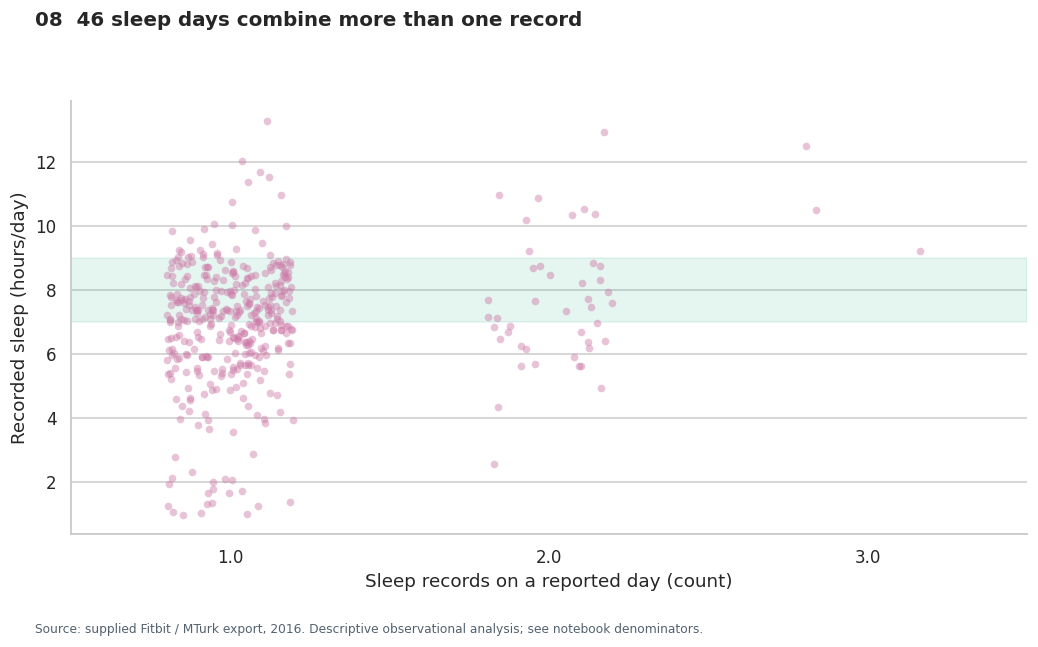

In [24]:
plot_chart(8, data)

**So what?** 46 of 410 unique sleep days contain multiple records. Their total may include naps or split sleep, so daily totals must not be presented as uninterrupted nightly sleep.

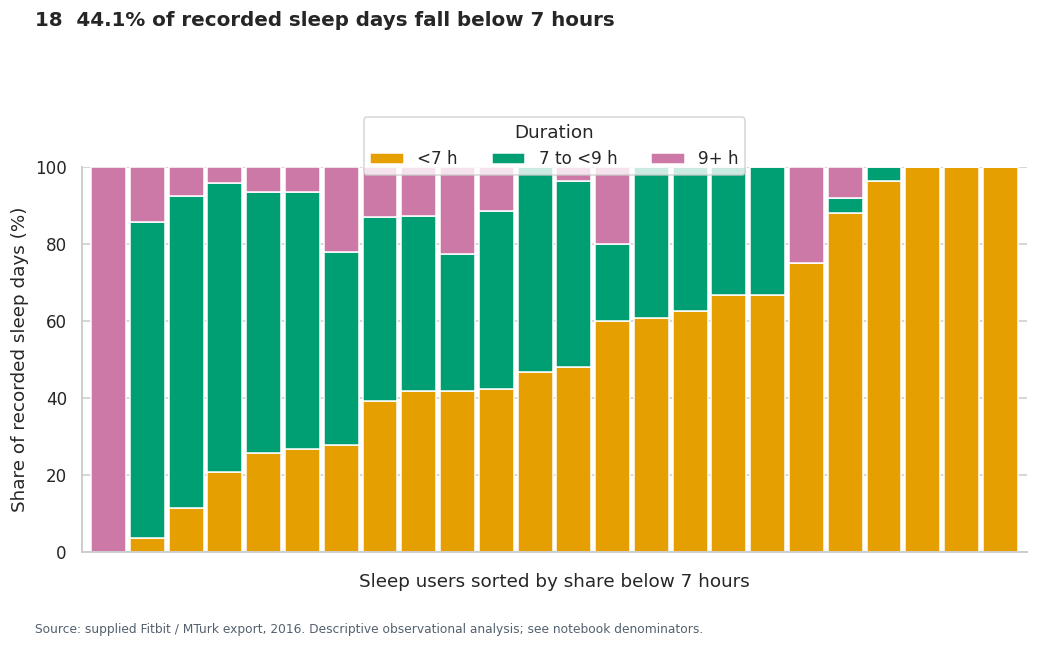

In [25]:
plot_chart(18, data)

**So what?** Mean recorded sleep is 419.2 minutes (6.99 hours); 44.1% of days are below seven hours. The 7–9-hour band is an analytical reference, not an individualized prescription.

Sleep needs depend on age, which is absent. CDC recommends seven or more hours for adults 18–60, 7–9 hours for ages 61–64 and 7–8 hours for 65+. Therefore this notebook does not label all 9+ hour records unhealthy. [CDC sleep guidance](https://www.cdc.gov/sleep/about/index.html).

**Sleep-onset latency is not identifiable here.** The in-bed minus asleep gap combines wakefulness before, during and after sleep; it is not time to fall asleep. `minuteSleep` has episode IDs and state codes, but no verified lights-out time and no attached state-code dictionary. All 459 deduplicated episodes are profiled without inventing a latency estimate.

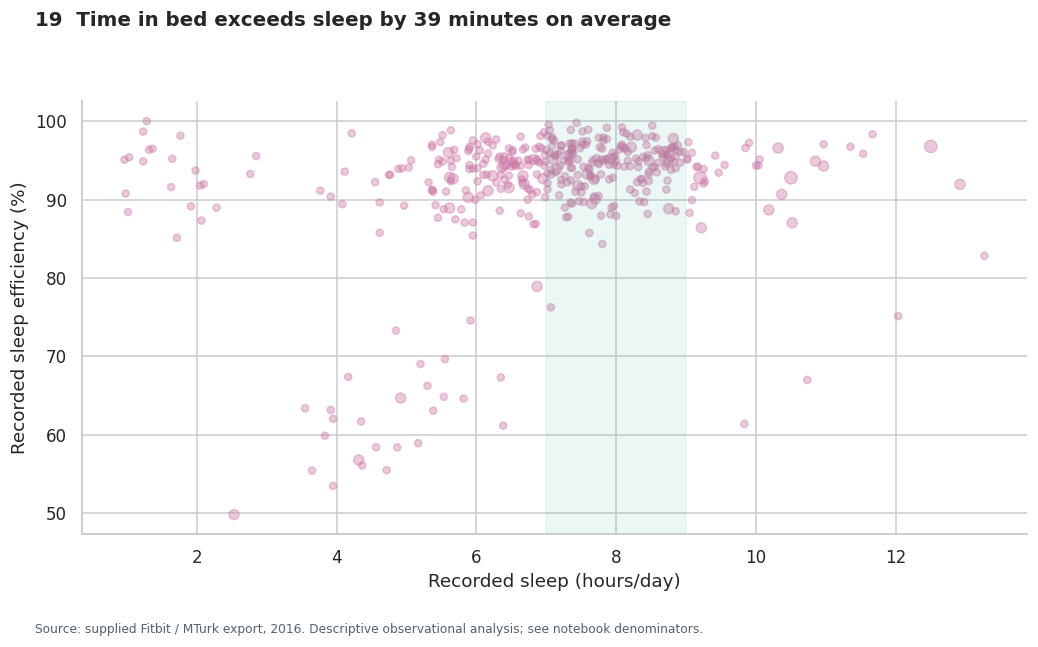

In [26]:
plot_chart(19, data)

**So what?** Mean record-level efficiency is 91.6% and the mean in-bed gap is 39.3 minutes. Use this as a logging discussion, not a sleep-disorder diagnosis.

In [27]:
display(data["lag_stats"])
display(data["episodes"].head(8))

,alignment,users,pairs,median_within_user_rho,ci_low,ci_high
0,previous,17,393,0.059628,0.000000,0.138340
1,same,18,408,-0.081940,-0.309789,0.029800
2,next,17,385,-0.000305,-0.138974,0.063774


,Id,logId,start_time,end_time,recorded_minutes,code_1_minutes,code_2_minutes,code_3_minutes
0,1503960366,11380564589,2016-04-12 02:47:30,2016-04-12 08:32:30,346,327,13,6
1,1503960366,11388770715,2016-04-13 03:08:30,2016-04-13 08:20:30,313,290,11,12
2,1503960366,11388770716,2016-04-13 20:10:00,2016-04-13 21:43:00,94,94,0,0
3,1503960366,11402722600,2016-04-15 02:59:00,2016-04-15 10:20:00,442,412,22,8
4,1503960366,11421831252,2016-04-16 02:11:00,2016-04-16 06:59:00,289,270,16,3
5,1503960366,11421831253,2016-04-16 07:02:00,2016-04-16 08:19:00,78,70,3,5
6,1503960366,11421831254,2016-04-16 23:27:00,2016-04-17 11:18:00,712,700,12,0
7,1503960366,11439580762,2016-04-19 02:06:30,2016-04-19 07:25:30,320,304,16,0


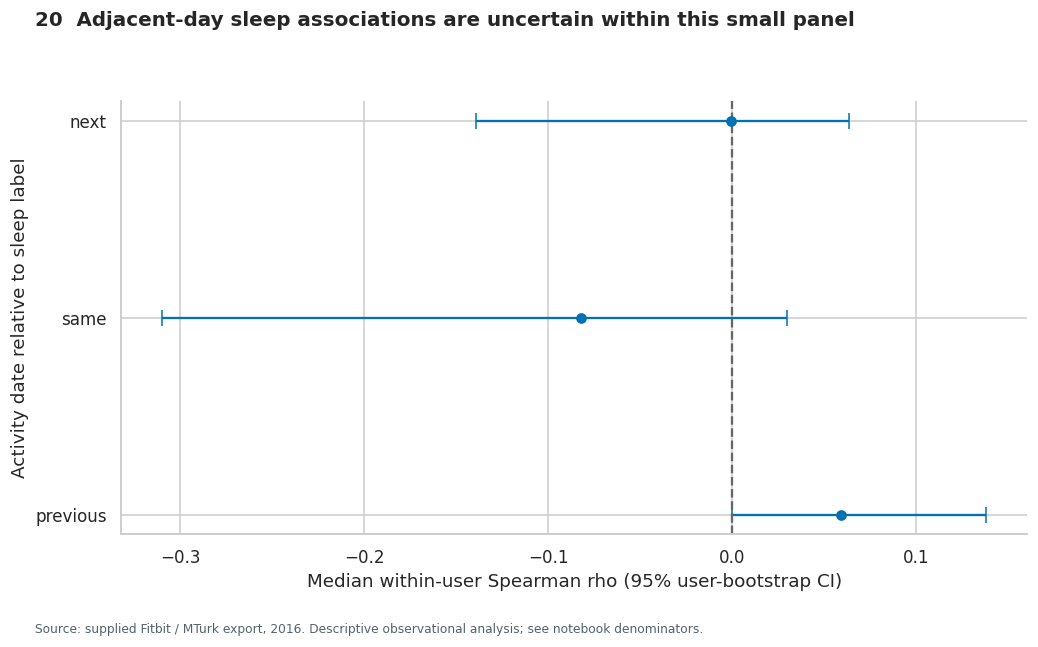

In [28]:
plot_chart(20, data)

**So what?** Sleep is aligned to the export SleepDay date. Previous/same/next activity means exact calendar dates, with no forward filling. User-level correlation medians and user-bootstrap intervals avoid treating each day as an independent participant.

<a id="section-8"></a>
## 8. Heart-rate and intensity analysis

**Takeaway:** Only 14 users have heart-rate data; observed intervals are not equivalent to all-day exposure.

In [29]:
display(pd.read_csv(BASE / "sql_outputs/heart_rate_zones.csv"))
display(data["resting"])

,bpm_band,observed_hours,readings,excluded_gaps
0,100-139,395.917778,253915,146
1,140+,29.593611,35092,6
2,60-99,4114.031111,1821636,1049
3,<60,1002.786389,373015,123


,Id,night_p10_bpm
0,2026352035,67.198630
1,2347167796,61.088763
2,4020332650,58.683855
3,4388161847,47.966836
4,4558609924,61.966810
5,5553957443,56.670000
6,5577150313,48.161194
7,6117666160,61.883084
8,6775888955,67.418266
9,6962181067,59.813838


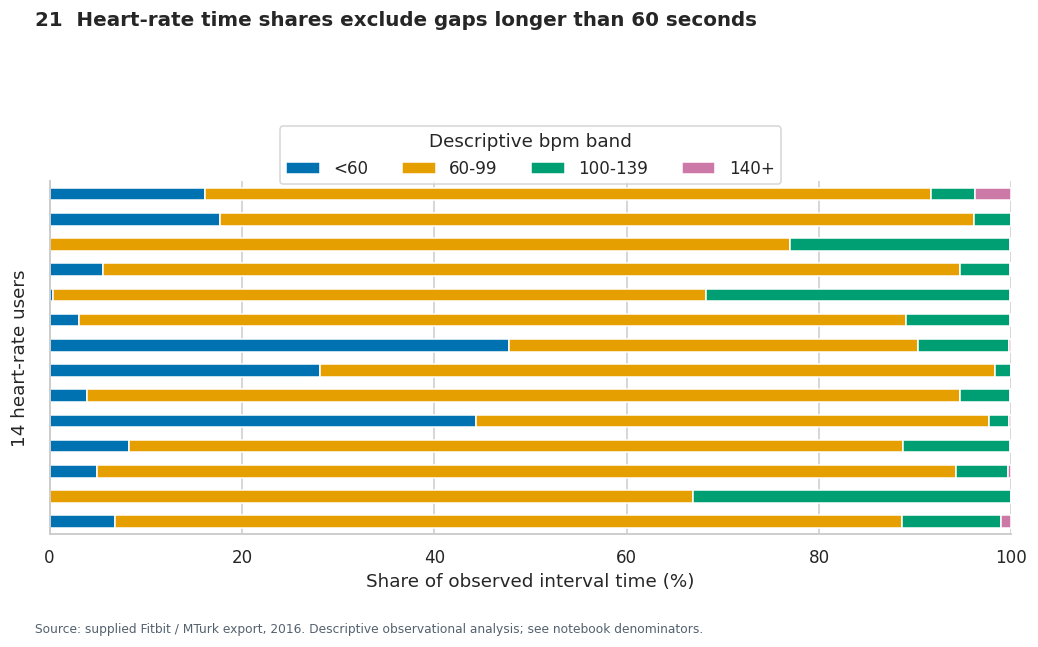

In [30]:
plot_chart(21, data)

**So what?** Bpm bands are fixed descriptive ranges (<60, 60–99, 100–139, 140+), not personalized training zones. Each reading carries its next observed interval only if that interval is positive and ≤60 seconds; gaps and terminal readings add no duration.

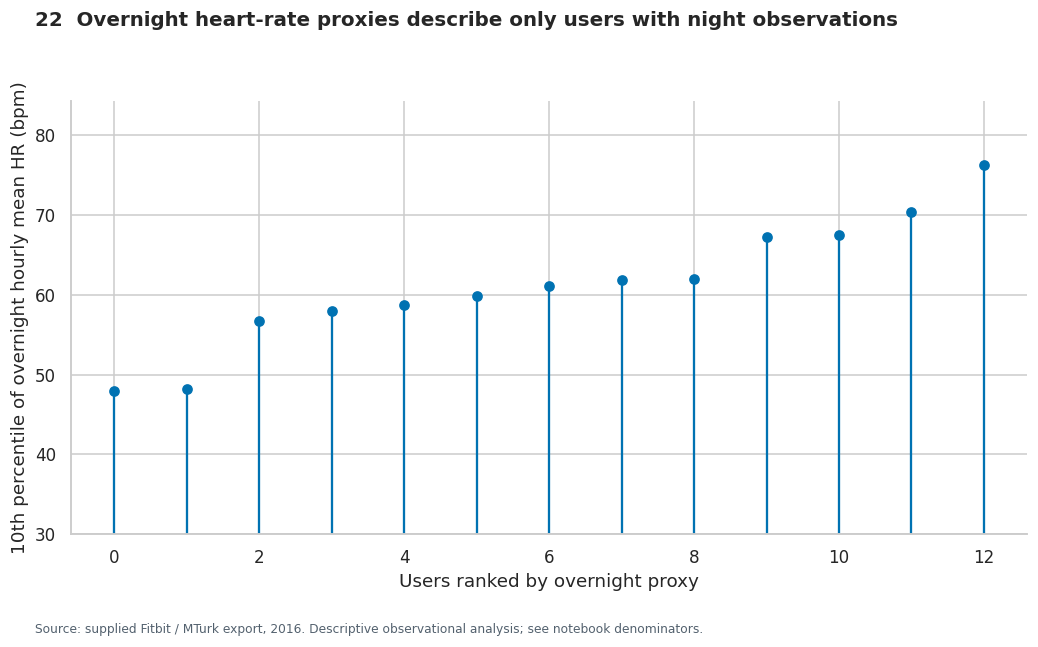

In [31]:
plot_chart(22, data)

**So what?** The overnight proxy is the 10th percentile of hourly mean bpm between 00:00 and 05:59, calculated separately by user. It is neither clinical resting heart rate nor a sleep-stage measurement; sparse night coverage can bias it.

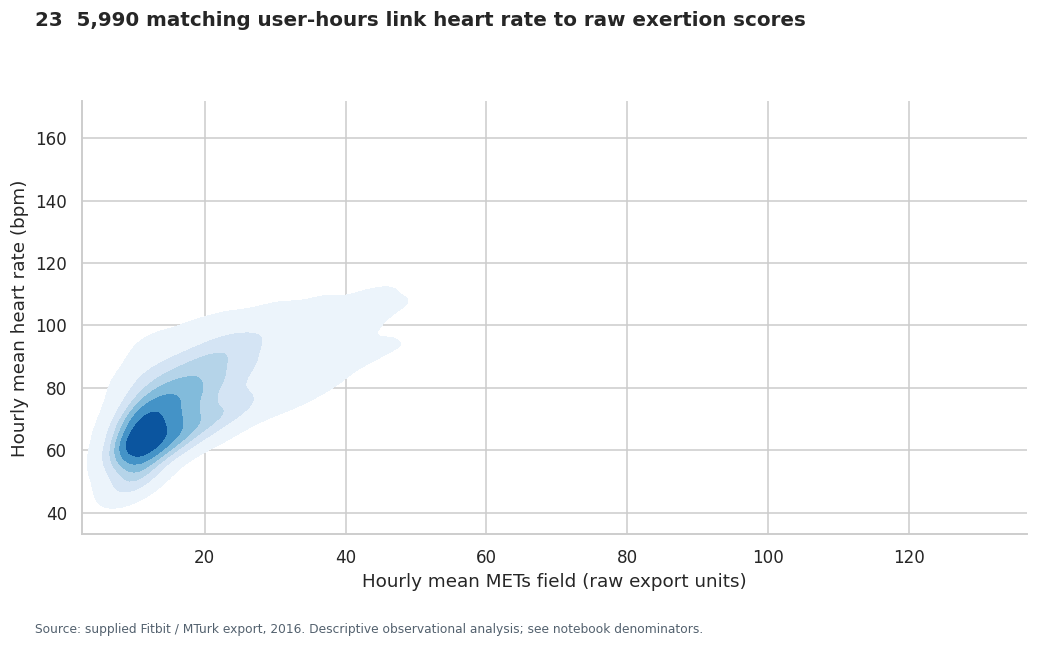

In [32]:
plot_chart(23, data)

**So what?** Only matching user-hours on retained activity dates enter this view. METs remains in raw export units. Repeated hourly observations and device algorithm overlap prevent an independent validation claim.

In [33]:
hr_user = data["hr_join"].groupby("Id")[["mean_bpm", "TotalIntensity", "mean_raw_mets"]].mean()
display(hr_user.corr(method="spearman").round(3))
print(f"HR/intensity/MET comparison: {len(data['hr_join']):,} hours, {len(hr_user)} users")

,mean_bpm,TotalIntensity,mean_raw_mets
mean_bpm,1.000,0.481,0.477
TotalIntensity,0.481,1.000,0.947
mean_raw_mets,0.477,0.947,1.000


HR/intensity/MET comparison: 5,990 hours, 14 users


<a id="section-9"></a>
## 9. Weight/BMI logging behaviour

**Takeaway:** The weight sample supports a feature-engagement observation, not a weight-management conclusion.

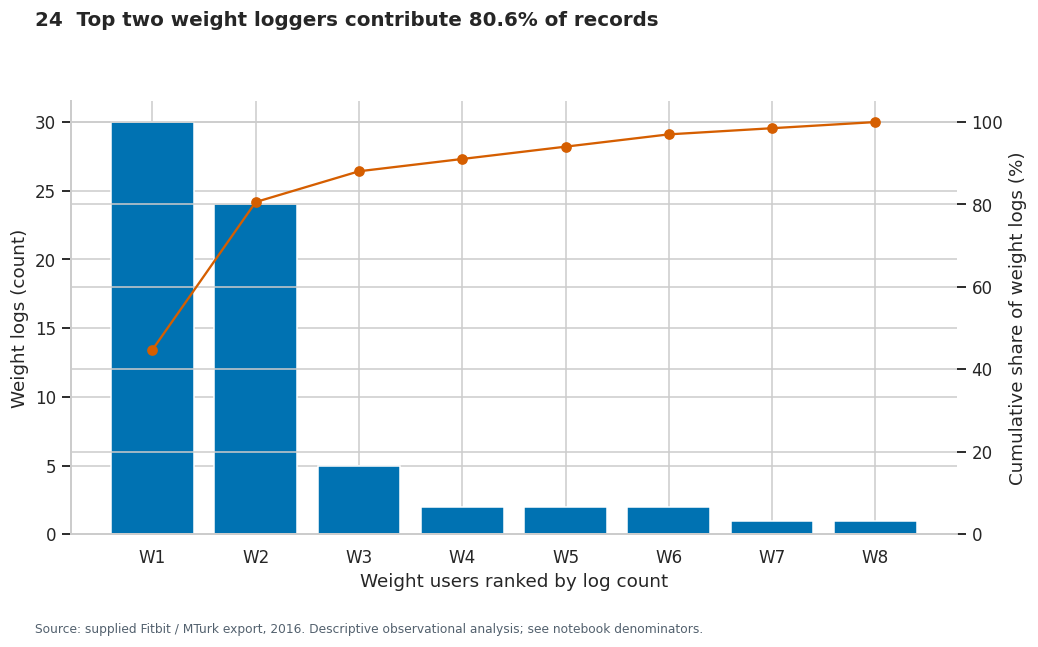

In [34]:
plot_chart(24, data)

**So what?** Highly concentrated logging makes record-weighted weight/BMI averages unrepresentative even of the eight loggers. Acquisition targeting based on body size would be unsupported.

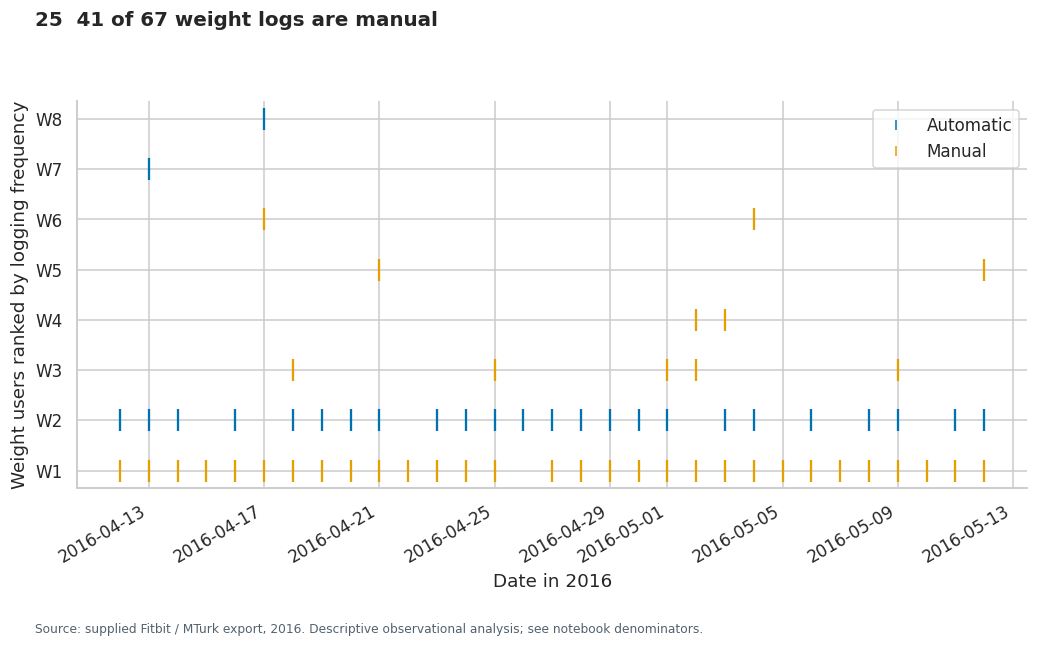

In [35]:
plot_chart(25, data)

**So what?** 41/67 logs (61.2%) are manually reported. Investigate logging friction with consented research; the data cannot explain why other users have no weight logs.

In [36]:
display(pd.read_csv(BASE / "sql_outputs/weight_behavior.csv"))

,Id,logs,days,manual_logs,missing_fat,mean_recorded_bmi
0,1503960366,2,2,2,1,22.650000
1,1927972279,1,1,0,1,47.540001
2,2873212765,2,2,2,2,21.570001
3,4319703577,2,2,2,1,27.415000
4,4558609924,5,5,5,5,27.214000
5,5577150313,1,1,0,1,28.000000
6,6962181067,30,30,30,30,24.028000
7,8877689391,24,24,0,24,25.487083


<a id="section-10"></a>
## 10. User segmentation

**Takeaway:** Interpretable rules guide a first test; KMeans is an exploratory cross-check on 33 users.

**Rule-based segments, in priority order:** Reconnect = fewer than 21 retained days; Build routine = at least 21 retained days and mean steps below 7,500; Keep momentum = remaining users. Thresholds are operational choices, not validated medical categories.

**KMeans:** one row per user; standardized mean steps, mean active-minute share and engagement score. Sleep and weight are excluded to avoid imputing sparse modalities; demographic features are unavailable. Candidate k=2…6 uses 30 initializations and fixed seed 42. Choose the highest silhouette, inspect the elbow and report the actual profile. Naming describes recorded behaviour and does not infer motivation or demographic identity.

In [37]:
display(u.groupby("rule_segment").agg(users=("Id", "size"), steps=("mean_steps", "mean"), engagement=("engagement_score", "mean")))
display(data["scores"])
display(data["profile"])

,users,steps,engagement
rule_segment,,,
Build routine,6,5822.283647,95.698925
Keep momentum,18,10161.087048,94.086022
Reconnect,9,5179.229452,51.254480


,k,inertia,silhouette
0,2,50.880982,0.411270
1,3,35.082541,0.329410
2,4,26.798397,0.317233
3,5,21.211531,0.328128
4,6,17.400303,0.324016


,cluster,mean_steps,mean_active_share,engagement_score,persona,users
0,0,5287.413164,0.141009,66.253102,Gentle starters,13
1,1,9785.498135,0.257818,93.387097,Routine builders,20


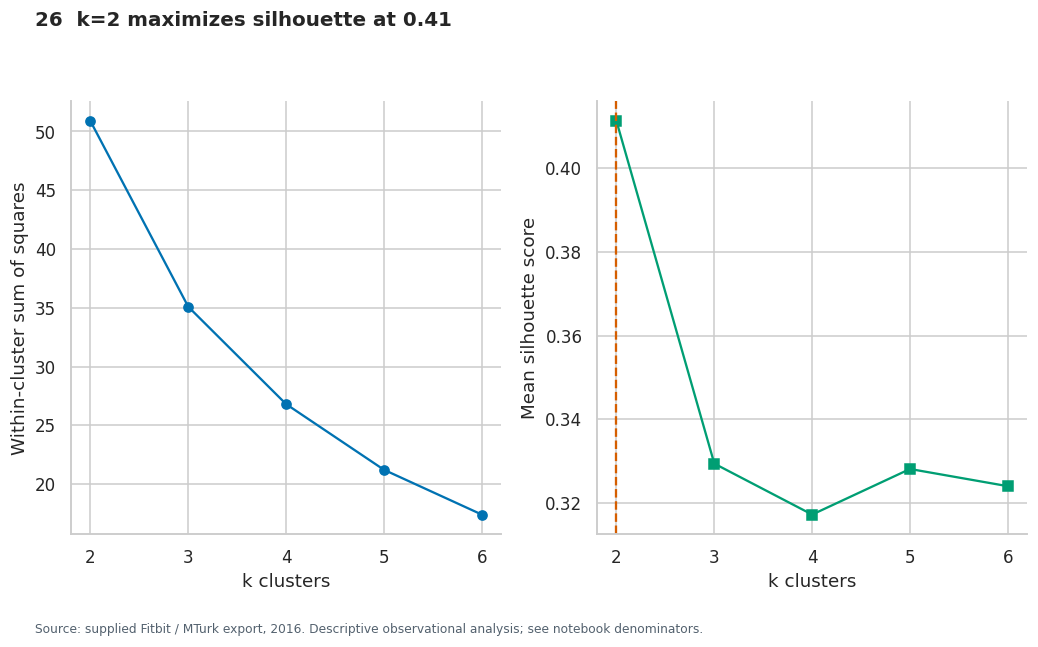

In [38]:
plot_chart(26, data)

**So what?** k=2 has silhouette 0.411; the elbow is shown as a secondary diagnostic. Ten alternate initialization seeds produce minimum adjusted Rand index 1.00. This tests initialization stability, not population or resampling stability.

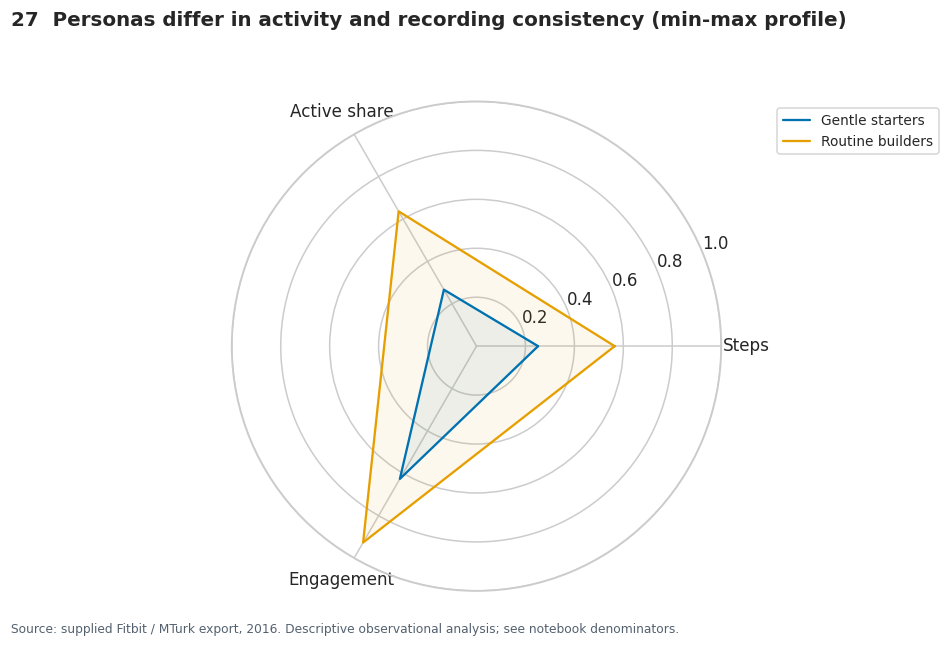

In [39]:
plot_chart(27, data)

**So what?** Each axis rescales the feature to the observed user minimum and maximum; polygons do not represent a composite wellness score. Use the adjacent profile table for the original values and persona counts.

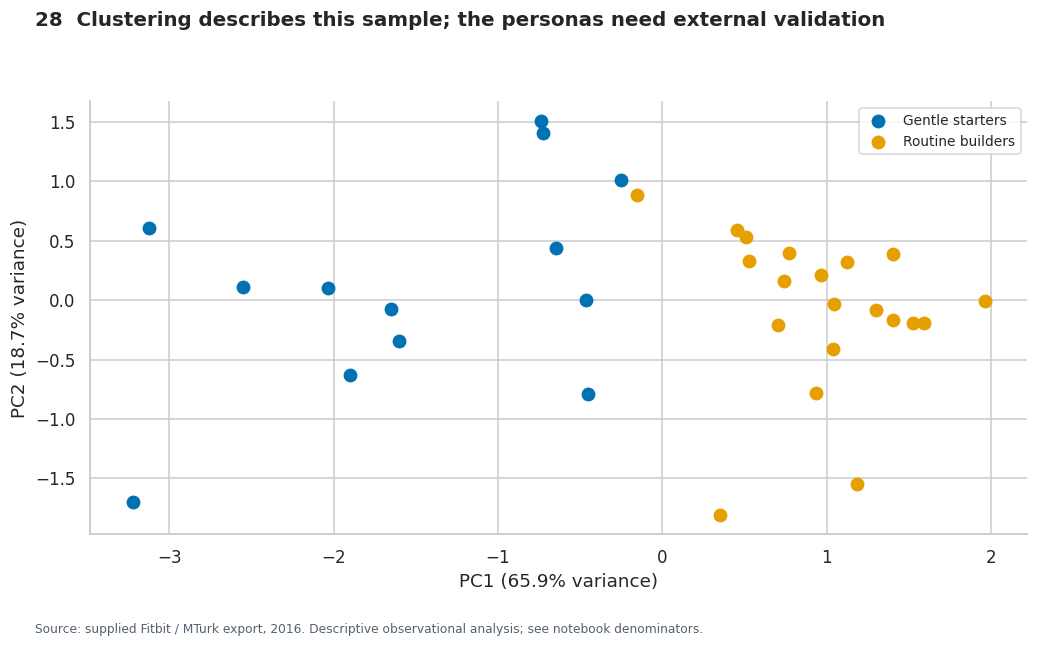

In [40]:
plot_chart(28, data)

**So what?** PCA only visualizes the standardized feature space. Clusters are sample descriptions; test future cohorts and resampling stability before operational assignment.

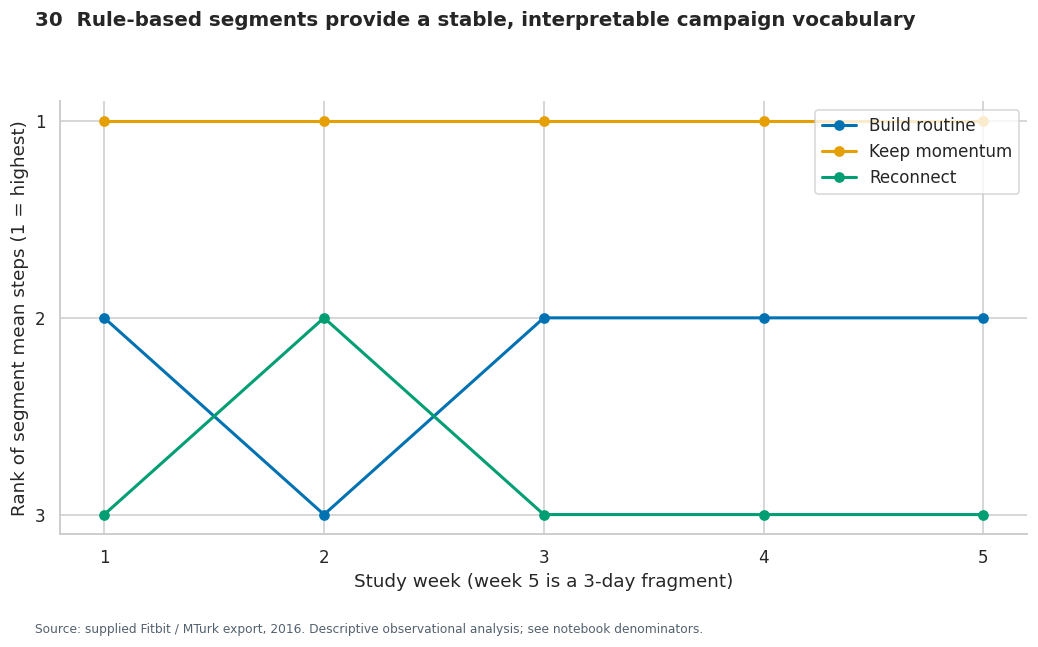

In [41]:
plot_chart(30, data)

**So what?** Rule segments are assigned from the full month, so their weekly separation is descriptive and partly built into the definition. A prospective campaign would assign segments using a prior observation period.

<a id="section-11"></a>
## 11. Statistical validation

**Takeaway:** Small user counts and repeated measures limit inferential strength; effect sizes and uncertainty take priority.

In [42]:
display(data["tests"].round(5))

,test,comparison,n,statistic,p_value,effect_size,effect_definition,p_holm
0,Shapiro-Wilk,mean_steps,33,0.98170,0.83597,NaN,W reported in statistic,NaN
1,Shapiro-Wilk,mean_active,33,0.96995,0.47884,NaN,W reported in statistic,NaN
2,Shapiro-Wilk,mean_calories,33,0.94995,0.13256,NaN,W reported in statistic,NaN
3,Spearman,mean_steps / mean_calories,33,0.31283,0.07630,0.31283,Spearman rho; one mean per user,0.38148
4,Spearman,mean_steps / mean_sleep,24,-0.13043,0.54353,-0.13043,Spearman rho; one mean per user,1.00000
5,Spearman,mean_active / mean_sleep,24,0.07130,0.74057,0.07130,Spearman rho; one mean per user,1.00000
6,Mann-Whitney U,Sleep loggers vs nonloggers: mean steps,33,114.00000,0.82406,0.05556,Cliff delta; positive favors sleep loggers,1.00000
7,Wilcoxon paired,Weekend minus weekday user mean steps,32,245.00000,0.73288,0.07197,Matched rank-biserial; positive favors weekend,1.00000


All between-user tests use one summary per user. Shapiro–Wilk checks are diagnostics, not proof of normality. Spearman tests assess monotonic associations. Mann–Whitney U compares the 24 sleep loggers against nine other users, with Cliff's delta as effect size. Wilcoxon pairs the 32 users with both weekday and weekend data, reporting rank-biserial effect size. Holm correction covers the five association/group hypotheses, while three normality diagnostics are separate.

The weekend confidence interval resamples users 2,000 times. Sleep lag confidence intervals resample eligible user correlations, requiring at least five complete pairs per user. These are exploratory estimates, not randomized treatment effects. No significance tests are run on clusters defined using the same activity features, which would be circular.

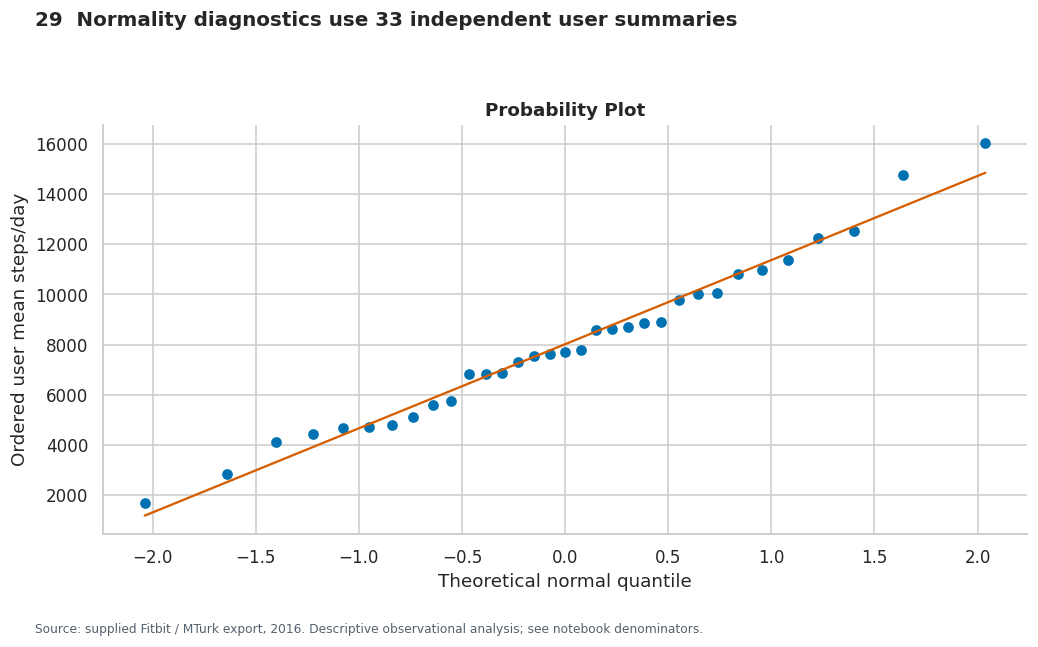

In [43]:
plot_chart(29, data)

**So what?** The user-level Shapiro tests do not reject normality at 0.05; that does not establish a normal population. Nonparametric tests retain a consistent approach for this small, selected panel.

**Inference summary:** none of the five association/group hypotheses survives the Holm-adjusted 0.05 threshold. This is not evidence that relationships do not exist; the sample is small, self-selected and lacks confounders. Daily and hourly charts remain descriptive. Marketing proposals are experiments justified by observed usage, not claimed effects on health or retention.

<a id="section-12"></a>
## 12. Key findings

**Takeaway:** The strongest evidence concerns recording quality, timing and uneven feature use.

1. **Coverage:** 33 activity users, 24 sleep users, 14 heart-rate users and eight weight users (Chart 01).
2. **Wear-quality sensitivity:** 94/940 activity days excluded; mean steps move from 7,638 to 8,427 under the proxy (Chart 03).
3. **Movement baseline:** 45.4% of retained days stay below 7,500 steps (Chart 04).
4. **Light activity dominates:** 84.7% of classified active minutes are light (Chart 16).
5. **Timing:** 18:00 is the pooled peak, 660 steps per observed hour (Chart 14).
6. **Sleep:** mean 419.2 minutes; 44.1% of unique sleep days below seven hours (Chart 18).
7. **Weekend uncertainty:** paired gap +120 steps/day, with 95% CI spanning -959 to +1143 (Chart 13).
8. **Weight friction hypothesis:** 41/67 logs manual and 65/67 missing Fat; eight users provide all weight records (Charts 02, 25).

<a id="section-13"></a>
## 13. Marketing recommendations: Bellabeat App/Membership

**Takeaway:** Test activity-led onboarding and optional sleep value before expanding a weight-led proposition.

| Recommendation              | Evidence                                                                       | Action                                                                                                | KPI                                                                                 |
|:----------------------------|:-------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------|
| Quality-aware onboarding    | 94/940 days excluded; raw/clean mean differs by 789 steps                      | Test opt-in setup/sync checks and explain missing data before issuing activity nudges                 | Retained recording days / eligible days; seven-day activation; notification opt-out |
| Personal baseline campaigns | 45.4% of retained days <7,500 steps; light activity is 84.7% of active minutes | Test incremental movement goals matched to prior activity and the rule personas                       | Change in user-level retained-day steps; goal engagement; adverse/negative feedback |
| Timing experiment           | 18:00 peak averages 660 steps per observed hour                                | Randomize individualized reminder timing against a fixed schedule and a no-reminder holdout           | Incremental weekly active days; prompt engagement; notification fatigue             |
| Optional sleep onboarding   | 24/33 sleep loggers; 44.1% of sleep days <7 h                                  | Test a sleep-summary onboarding path and consistent-routine content for consenting users              | Sleep-feature activation; 14-day logging continuity; membership conversion          |
| Keep weight optional        | 8/33 weight loggers; 41/67 entries manual                                      | Prioritize activity/sleep value messages; interview weight loggers before adding weight-led campaigns | Feature opt-in and completion; entry burden; D30 retention by randomized arm        |

**Measurement design:** recruit a contemporary, consented Bellabeat target-market cohort; assign experiments at user level, using prior-period segments. Predefine one primary KPI and guardrails, minimum detectable effect and power before sample sizing. Track missingness as an outcome; improved retention can change the observed activity mix. Randomize within baseline segment, use intention-to-treat reporting and report confidence intervals. Subscription conversion and true app retention are **future instrumentation requirements**; neither can be estimated from the supplied files. No numeric uplift forecast is defensible here.

<a id="section-14"></a>
## 14. Limitations, bias and next steps

**Takeaway:** This ten-year-old convenience sample generates testable hypotheses, not a representative market forecast.

- **Population:** 33 self-selected MTurk activity users, with no age, sex, height, profession, geography or confirmed membership in Bellabeat's audience. No women-specific inference is made.
- **Time:** one 31-day interval in 2016; the last day and several user histories are partial. No seasonal or long-term habit claim is supportable.
- **Missingness:** absent sleep/weight/HR may reflect devices, permissions or export coverage rather than preference. Nonwear cannot be confirmed. Conditioning on the quality proxy can bias activity upward; thresholds are sensitivity-tested.
- **Measurement:** proprietary classifications and calorie estimates; raw distance/intensity/MET units not verified. No calorie intake, stress, menstrual-cycle or health-outcome evidence exists.
- **Sleep:** daily labels and multiple episodes limit nightly interpretation; no reliable sleep-onset latency. Adjacent-day alignment is an explicit calendar convention.
- **Statistics:** repeated measurements, sparse weight logs, modest independent user counts and multiple exploratory questions. No causal effects; cluster initialization stability is not external validity.
- **Commercial evidence:** no acquisition, subscription, notification exposure, retention instrumentation or revenue data.

**Next steps:** validate a source dictionary and timezone metadata; collect on-body wear signals and enrollment dates; instrument opt-in app events; recruit a representative target cohort; pre-register randomized onboarding/reminder tests; externally validate personas. The processed tables are prepared for later Power BI and Streamlit work, which is intentionally deferred.

<a id="section-15"></a>
## 15. Appendix: reproducibility and reconciliation

**Takeaway:** Python and SQL agree on every selected parity metric and rule-segment count.

In [44]:
display(data["recon"])
assert data["recon"]["match"].all()
print("All reconciliation checks passed.")
print(f"Charts saved: {len(list((BASE / 'charts').glob('chart_*.png')))}")

,metric,python,sql,match
0,activity_users,33.000000,33.000000,True
1,clean_activity_rows,846.000000,846.000000,True
2,average_steps,8426.832151,8426.832151,True
3,clean_sleep_rows,410.000000,410.000000,True
4,average_sleep_minutes,419.173171,419.173171,True
5,clean_weight_rows,67.000000,67.000000,True
6,segment: Keep momentum,18.000000,18.000000,True
7,segment: Reconnect,9.000000,9.000000,True
8,segment: Build routine,6.000000,6.000000,True


All reconciliation checks passed.
Charts saved: 30


**Rebuild order:** create a Python environment from `requirements.txt`; import the 18 CSVs with `load_csv_to_sqlite.py`; execute `run_sql.py`; run this notebook top to bottom. `run_all.py --raw-dir ../raw` automates import, SQL, notebook execution and HTML/PDF export. SQL stores ISO dates as TEXT; date normalization happens explicitly at import, never via SQLite's ambiguous interpretation of US dates.

**Traceability:** `source_inventory` records file hashes, rows, columns, users and bounds; `column_audit` records every field; `cleaning_log` records transformations; `sql_outputs/execution_log.csv` lists every executed master-SQL statement; `reconciliation` compares independently cleaned pandas data to SQL. CSV and parquet pairs share each processed table's rows. IDs remain 64-bit integers; treat them as identifiers in downstream tools. Date fields and joins are documented in `processed/DATA_DICTIONARY.md`.

**Chart register:** 30 distinct numbered views. Chart 01 modality adoption bars; 02 missing-cell audit; 03 threshold sensitivity; 04 histogram/KDE; 05 ECDF; 06 box plots; 07 violins; 08 sleep-record strip plot; 09 correlation matrix; 10 hexbin; 11 regression/CI; 12 lollipop; 13 paired dumbbell; 14 hour×weekday heatmap; 15 calendar heatmap; 16 stacked area; 17 trend/coverage panels; 18 sleep composition; 19 efficiency bubble plot; 20 lag-association intervals; 21 observed HR-time composition; 22 overnight proxy stems; 23 bivariate KDE contours; 24 Pareto; 25 event timeline; 26 elbow/silhouette diagnostics; 27 radar; 28 PCA cluster projection; 29 Q–Q; 30 segment-rank bump chart. Reused visual primitives answer different questions at different grains; no chart is a cosmetic recolouring of another.

**External references:** [WHO activity guidance](https://www.who.int/news-room/fact-sheets/detail/physical-activity), [CDC sleep guidance](https://www.cdc.gov/sleep/about/index.html). Step bands follow the task's requested historical descriptive convention, not a CDC universal 10,000-step requirement. Product strategy is scoped to the supplied case brief rather than asserted current Bellabeat features.

**Execution environment:** all cells were executed sequentially with IPython and real outputs captured because this hosted environment disallows kernel sockets. `execute_notebook.py` supplies that reproducible path; ordinary Jupyter/nbclient execution remains supported. No error outputs were suppressed or fabricated.

In [46]:
import platform
import sqlite3
from importlib.metadata import version, PackageNotFoundError

packages = [
    "pandas", "numpy", "scipy", "scikit-learn",
    "matplotlib", "seaborn", "pyarrow",
    "nbformat", "nbclient", "nbconvert", "weasyprint"
]

versions = {}

for name in packages:
    try:
        versions[name] = version(name)
    except PackageNotFoundError:
        versions[name] = "Not installed"

versions["python"] = platform.python_version()
versions["sqlite"] = sqlite3.sqlite_version

pd.Series(versions, name="version").to_csv(
    BASE / "processed" / "software_versions.csv"
)

display(pd.Series(versions, name="version"))

pandas                  3.0.3
numpy                   2.4.6
scipy                  1.17.1
scikit-learn            1.9.0
matplotlib             3.10.9
seaborn                0.13.2
pyarrow                24.0.0
nbformat               5.10.4
nbclient               0.11.0
nbconvert              7.17.1
weasyprint      Not installed
python                 3.14.5
sqlite                 3.50.4
Name: version, dtype: str